In [1]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from matplotlib.gridspec import GridSpec

from hbn.constants import Defaults  
from hbn.visualization import make_tables, visualize as vis, raw_scores
from hbn.visualization import utils as utils

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [2]:
from hbn.features.build_features import _index_dataframe_by_columns_values

def plot_data(df, col='DX_Subtype_Name', x='score_names', y='scores', hue='Sex', kind='bar'):
    g = sns.catplot(
        data=df, x=x, y=y, hue=hue, col=col,
        kind=kind, height=4, aspect=.6,
    )

    g.set_axis_labels("", "% taking medication")
    g.set_xlabels("")
    g.set_titles("{col_name}")

    return g

def get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx='DX_Subtype_Name',
        dx_to_include=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
        cols_to_filter=None
        ):

    # get raw data
    df, cols_to_filter = raw_scores.get_data(
        assessment=assessment, 
        dx=dx, 
        measure=measure,
        cols_to_filter=cols_to_filter, 
        )

    # filter data
    columns = ['Sex', dx, 'Age_round']
    values_list = [['male', 'female'], dx_to_include, np.arange(6,18)]
    df_filter = _index_dataframe_by_columns_values(dataframe=df, columns=columns, values_list=values_list)

    return df_filter

def get_med_df(df, groupby=['DX_Subtype_Name', 'Sex']):

    def _calculate_perc_med(df, med='cur'):
        # calculate % people who are currently taking a medication
        curr_med = len(df[df[f'PreInt_TxHx,psych_meds_{med}']==1])
        total = df.shape[0]
        return (curr_med / total) * 100
    
    # calculate number of kids taking medication across sex and subtypes
    df_med_all = pd.DataFrame()
    for med in ['cur', 'past']:
        df_med = df.groupby(groupby).apply(lambda x: _calculate_perc_med(x, med=med)).reset_index(name=f'{med}')
        df_med_all = pd.concat([df_med_all, df_med], axis=1)
    df_med_all = df_med_all.loc[:,~df_med_all.columns.duplicated()]

    # get data for plot
    grouped_df = pd.melt(df_med_all, value_vars=['cur', 'past'], 
            id_vars=groupby) \
            .rename(columns={'variable': 'score_names', 'value': 'scores'})
    grouped_df['score_names'] = grouped_df['score_names'].replace({'cur':'currently', 'past':'past'})

    return grouped_df


def _calculate_perc(df, col):
    # calculate % people who respond "1" to a question 
    count = len(df[df[col]==1])
    total = df.shape[0]
    return (count / total) * 100

def get_col_perc(df, groupby=['DX_Subtype_Name', 'Sex'], col='PreInt_TxHx,suicide'):
    
    # calculate counts for `col`
    df_grouped = df.groupby(groupby).apply(lambda x: _calculate_perc(x, col)).reset_index(name=col)

    # get data for plot
    grouped_df = pd.melt(df_grouped, value_vars=[col], 
            id_vars=groupby) \
            .rename(columns={'variable': 'score_names', 'value': 'scores'})

    return grouped_df

## % of kids taking medication

<Axes: ylabel='% currently taking psychiatric medications'>

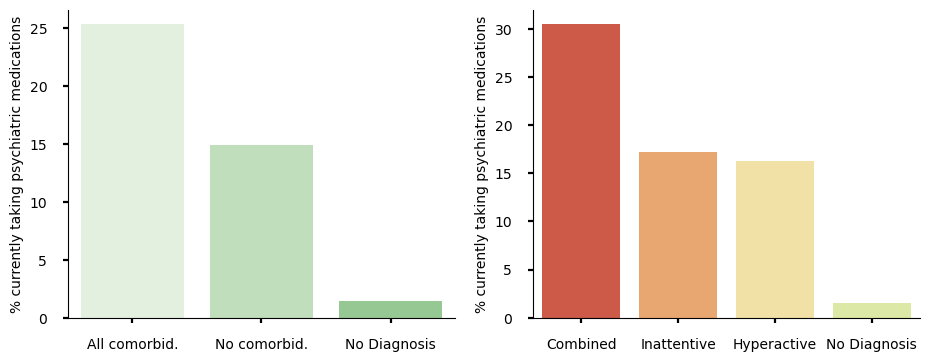

In [4]:
vis.plotting_style(palette='Set2')
fig = plt.figure(figsize=(11,4))
gs = GridSpec(1, 2, figure=fig)

# B # 
dx = 'DX_ADHD'
dx_to_include  = ['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis']

# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )

# calculate % people who are currently taking a medication
df_med_all = get_med_df(df, groupby=[dx])

vis.plotting_style(palette='Greens')
ax = fig.add_subplot(gs[0, 0])
df1 = df_med_all[df_med_all['score_names']=='currently']
vis.barplot(x='DX_ADHD',
        y='scores',
        xticklabels=['All comorbid.', 'No comorbid.', 'No Diagnosis'],
        ylim=None, 
        ylabel='% currently taking psychiatric medications',
        data=df1, 
        ax=ax)

# C # 
dx = 'DX_Subtype_Name'
dx_to_include  = ['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)', 'No Diagnosis']

# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )

# calculate % people who are currently taking a medication
df_med_all = get_med_df(df, groupby=[dx])

vis.plotting_style(palette='RdYlGn')
ax = fig.add_subplot(gs[0, 1])
df1 = df_med_all[df_med_all['score_names']=='currently']
vis.barplot(x='DX_Subtype_Name',
        y='scores',
        xticklabels=['Combined', 'Inattentive', 'Hyperactive', 'No Diagnosis'],
        order=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)', 'No Diagnosis'],
        ylim=None, 
        ylabel='% currently taking psychiatric medications',
        data=df1, 
        ax=ax)

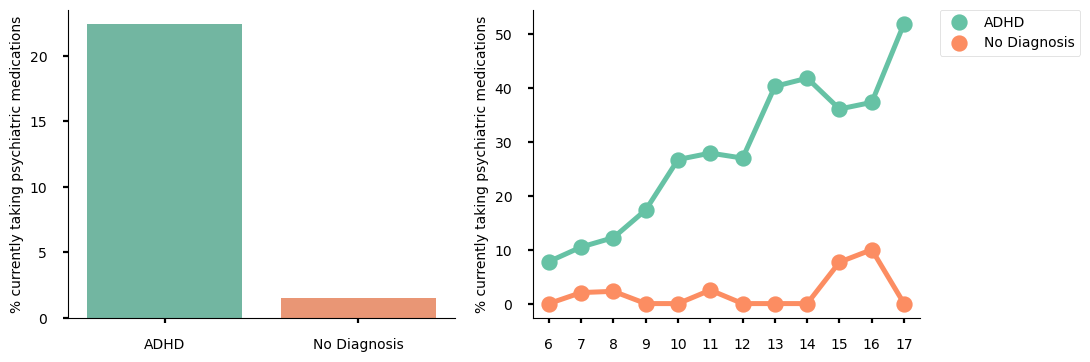

In [32]:
vis.plotting_style(palette='Set2')
fig = plt.figure(figsize=(11,4))
gs = GridSpec(1, 2, figure=fig)

# A # 
dx = 'DX_ADHD'
dx_to_include  = ['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis']

# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )
df['DX_ADHD_binary'] = df['DX_ADHD'].str.extract('(ADHD|No Diagnosis)')

# A # 
ax = fig.add_subplot(gs[0, 0])
# calculate % people who are currently taking a medication
df_med_all = get_med_df(df, groupby=['DX_ADHD_binary'])
df1 = df_med_all[df_med_all['score_names']=='currently']
vis.barplot(x='DX_ADHD_binary',
        y='scores',
        order=['ADHD', 'No Diagnosis'],
        ylim=None, 
        ylabel='% currently taking psychiatric medications',
        data=df1, 
        ax=ax)

# B # 
ax = fig.add_subplot(gs[0, 1])
# calculate % people who are currently taking a medication
df_med_all = get_med_df(df, groupby=['DX_ADHD_binary', 'Age_round'])
df1 = df_med_all[df_med_all['score_names']=='currently']
ax = vis.pointplot(
        x='Age_round',
        y='scores',
        hue='DX_ADHD_binary',
        # order=['ADHD', 'No Diagnosis'],
        ylim=None, 
        ylabel='% currently taking psychiatric medications',
        data=df1, 
        ax=ax)
ax.get_legend().set_bbox_to_anchor((1.05, 1))

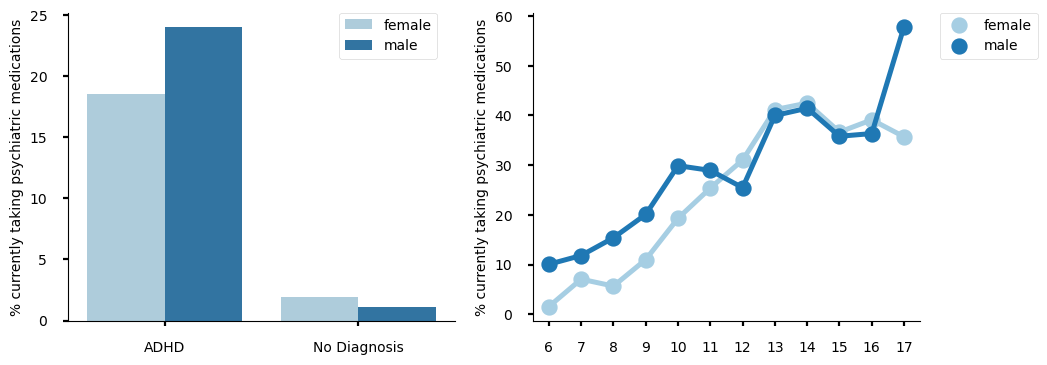

In [11]:
vis.plotting_style(palette='Paired')
fig = plt.figure(figsize=(11,4))
gs = GridSpec(1, 2, figure=fig)

# A # 
dx = 'DX_ADHD'
dx_to_include  = ['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis']

# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )
df['DX_ADHD_binary'] = df['DX_ADHD'].str.extract('(ADHD|No Diagnosis)')

# A # 
ax = fig.add_subplot(gs[0, 0])
# calculate % people who are currently taking a medication
df_med_all = get_med_df(df, groupby=['DX_ADHD_binary', 'Sex'])
df1 = df_med_all[df_med_all['score_names']=='currently']
ax = vis.barplot(x='DX_ADHD_binary',
        y='scores',
        order=['ADHD', 'No Diagnosis'],
        hue='Sex',
        ylim=None, 
        ylabel='% currently taking psychiatric medications',
        data=df1, 
        ax=ax)
ax.get_legend().set_bbox_to_anchor((.7, 1))

# B # 
ax = fig.add_subplot(gs[0, 1])
# calculate % people who are currently taking a medication
df_med_all = get_med_df(df, groupby=['DX_ADHD_binary', 'Age_round', 'Sex'])
df1 = df_med_all[(df_med_all['score_names']=='currently') & (df_med_all['DX_ADHD_binary']!='No Diagnosis')]
ax = vis.pointplot(
        x='Age_round',
        y='scores',
        hue='Sex',
        ylim=None, 
        ylabel='% currently taking psychiatric medications',
        data=df1, 
        ax=ax)
ax.get_legend().set_bbox_to_anchor((1.05, 1))

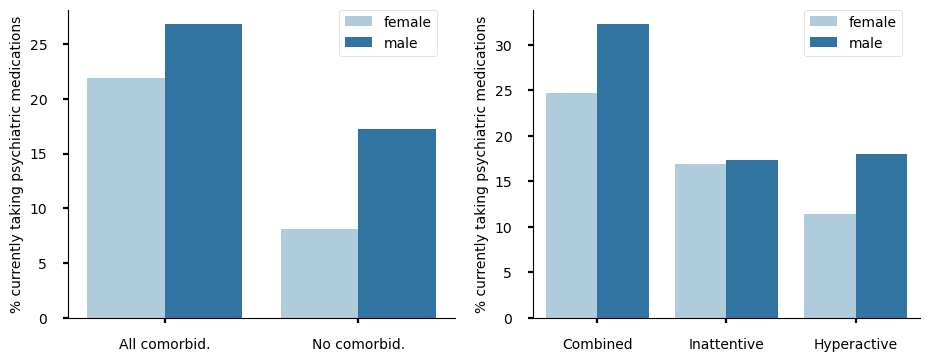

In [45]:
dx = 'DX_Subtype_Name'
dx_to_include  = ['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)', 'No Diagnosis']

# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )

# calculate % people who are currently taking a medication
df_med_all = get_med_df(df, groupby=[dx, 'Sex'])

vis.plotting_style(palette='Paired')
fig = plt.figure(figsize=(11,4))
gs = GridSpec(1, 2, figure=fig)

# A # 
ax = fig.add_subplot(gs[0, 1])
df1 = df_med_all[df_med_all['score_names']=='currently']
ax = vis.barplot(x='DX_Subtype_Name',
        y='scores',
        hue='Sex',
        xticklabels=['Combined', 'Inattentive', 'Hyperactive'],
        order=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
        ylim=None, 
        # legend=False,
        ylabel='% currently taking psychiatric medications',
        data=df1, 
        ax=ax)
ax.get_legend().set_bbox_to_anchor((.7, 1))

dx = 'DX_ADHD'
dx_to_include  = ['ADHD (all comorbid.)', 'ADHD (no comorbid.)']

# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )

# calculate % people who are currently taking a medication
df_med_all = get_med_df(df, groupby=[dx, 'Sex'])

ax = fig.add_subplot(gs[0, 0])
df1 = df_med_all[df_med_all['score_names']=='currently']
vis.barplot(x='DX_ADHD',
        y='scores',
        hue='Sex',
        xticklabels=['All comorbid.', 'No comorbid.'],
        ylim=None, 
        ylabel='% currently taking psychiatric medications',
        data=df1, 
        legend=True,
        ax=ax)
ax.get_legend().set_bbox_to_anchor((.7, 1))

Text(0.5, 0, '')

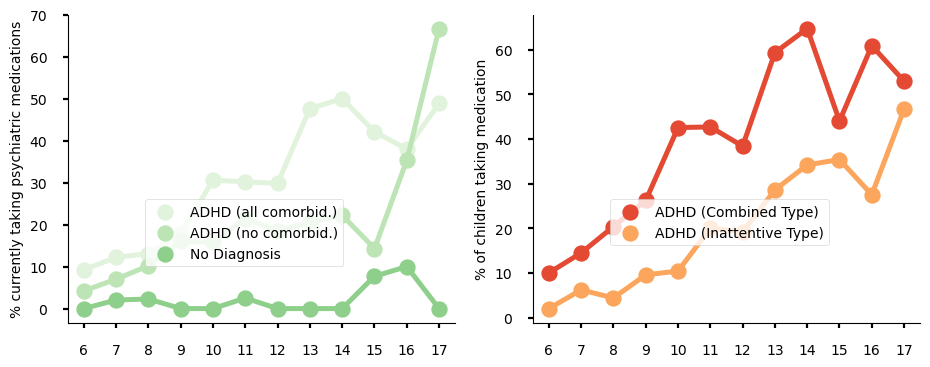

In [27]:
# A # 
dx = 'DX_ADHD'
dx_to_include  = ['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis']

# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )

# calculate % people who are currently taking a medication
df_med_all = get_med_df(df, groupby=[dx, 'Age_round'])

vis.plotting_style(palette='Greens')
fig = plt.figure(figsize=(11,4))
gs = GridSpec(1, 2, figure=fig)

ax = fig.add_subplot(gs[0, 0])
df1 = df_med_all[df_med_all['score_names']=='currently']
df1[dx] = df1[dx].rename({'ADHD (all comorbid.)': 'All comorbid.', 'ADHD (no comorbid)': 'No comorbid.', 'No Diagnosis': 'No Diagnosis'})
vis.pointplot(
    x='Age_round',
        y='scores',
        hue=dx,
        ylim=None, 
        ylabel='% currently taking psychiatric medications',
        data=df1, 
        ax=ax)
# ax.get_legend().remove()
ax.set_xlabel('')

# B # 
dx = 'DX_Subtype_Name'
dx_to_include  = ['ADHD (Combined Type)', 'ADHD (Inattentive Type)']

# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )

# calculate % people who are currently taking a medication
df_med_all = get_med_df(df, groupby=[dx, 'Age_round'])
# B
vis.plotting_style(palette='RdYlGn')
ax = fig.add_subplot(gs[0, 1])
df1 = df_med_all[df_med_all['score_names']=='currently']
df1[dx] = df1[dx].rename({'ADHD (Combined Type)': 'Combined', 'ADHD (Inattentive Type)': 'Inattentive'})
ax = vis.pointplot(data=df1, x='Age_round', ylim=None, ylabel='% of children taking medication', y='scores', hue=dx, ax=ax)
ax.set_xlabel('')


## What types of medications are children taking? 

In [32]:
### FUNCTIONS ###

def map_med_type():
    # assign medication types to groups
    med_groups = ['adhd_medications', 'mood_stabiliziers', 'antipsychotics']
    med_types = [
                ['Concerta', 'Stimulant', 'ADHD-Stimulant', 
                'Adderall', 'stimulant', 'Ritalin', 'Vyvanse - 2 years ago',
                'ADHD-Non Stimulant', 'Intuniv ER'],
                ['Zoloft', 'Lexapro - nothing', 'Antianxiety Drugs', 'Mood Stabilizers',
                'Buspar', 'Other Anti-Depressants', 'Tricyclics', 'SSRI'],
                ['Antipsychotics', 'Latuda - nothing', 'Abiify']
                ]

    df_med_all = pd.DataFrame()
    for med, med_type in zip(med_groups, med_types):
        df_med = pd.DataFrame()
        df_med['med_group'] = np.tile(med, len(med_type))
        df_med['med_type'] = med_type
        df_med_all = pd.concat([df_med_all, df_med], axis=0)

    return df_med_all

def check_med_type(x, med_type='cur'):

    if med_type=='cur':
        cols = range(1,6)
    elif med_type=='past':
        cols = range(6,11)

    # get list of cur med cols
    med_cols = [f'PreInt_TxHx,pmed_{str(i).zfill(2)}_type' for i in cols]

    # get mapping between med types and med groups
    df_med = map_med_type()

    # check to see if patient is currently taking medication
    medicated = x[f'PreInt_TxHx,psych_meds_{med_type}']==1
    
    # loop over med col
    adhd_meds_count, mood_meds_count, anti_meds_count = 0, 0, 0
    if medicated.values[0]:
        for med_col in med_cols:

            # check if med is in med group
            med = x[med_col].unique()[0]
            if med in df_med['med_type'].tolist():
                med_group = df_med[df_med['med_type']==med]['med_group'].values[0]
                if med_group == 'adhd_medications':
                    adhd_meds_count += 1
                elif med_group == 'mood_stabiliziers':
                    mood_meds_count += 1
                elif med_group == 'antipsychotics':
                    anti_meds_count += 1

    df_out = pd.DataFrame.from_dict(
                {f'adhd_medications_{med_type}': [adhd_meds_count], 
                f'mood_stabiliziers_{med_type}': [mood_meds_count], 
                f'antipsychotics_{med_type}': [anti_meds_count]}
                )
    return df_out

def _calculate_perc_count(x, count):
   # calculate number of medications above 0
   med_count = x[x[count]>0]['count'].sum()

   total_count = x['count'].sum()
   return (med_count / total_count) * 100

def get_medications(dx='DX_Subtype_Name', 
                     dx_to_include=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)', 'No Diagnosis']
                     ):

   # get data
   df = get_data(
         measure='PreInt_TxHx',
         assessment='Parent',
         dx=dx,
         dx_to_include=dx_to_include
         )

   # figure out medications for each participant
   df_all = pd.DataFrame()
   for name, group in df.groupby(['Identifiers']):
      df_curr = check_med_type(group, med_type='cur')
      df_past = check_med_type(group, med_type='past')
      df_concat = pd.concat([group.reset_index(drop=True), df_curr, df_past], axis=1)
      df_all = pd.concat([df_all, df_concat])
   
   return df_all

def calculate_perc_meds(df_medications, groupby=['DX_Subtype_Name'], medications=['adhd_medications', 'mood_stabiliziers', 'antipsychotics']):
    df_med_all = pd.DataFrame()
    for medication in medications:

        # groupby sex and subtype and get counts
        adhd_med_grouped = df_medications.groupby(groupby) \
                        .apply(lambda x: x[f'{medication}_cur'] \
                        .value_counts().reset_index(name='count')).reset_index() \
                                .rename(columns={'level_1': 'number_of_medications', 'level_2': 'number_of_medications', 'level_3': 'number_of_medications'})

        # calculate percentage
        df_med_perc = adhd_med_grouped.groupby(groupby).apply(lambda x: _calculate_perc_count(x, count='number_of_medications')).reset_index(name='perc')
        df_med_perc['med_type'] = 'current'
        df_med_perc['medication'] = medication

        df_med_all = pd.concat([df_med_all, df_med_perc], axis=0)
    
    return df_med_all

### Get medication data

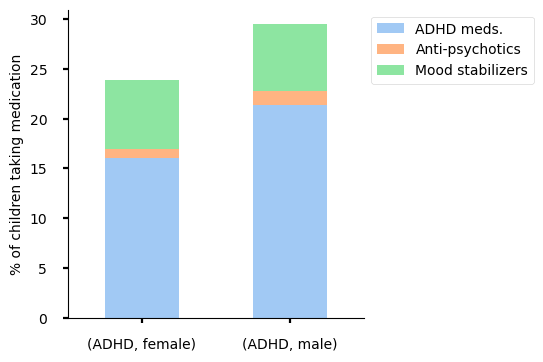

In [36]:

# get medications for each subtype
df_medications_all = get_medications(dx='DX_ADHD', 
                    dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)']
                    )

df_medications_all['DX_ADHD_binary'] = df_medications_all['DX_ADHD'].str.extract('(ADHD)')

# # calculate perc of people who are currently taking each medication
df_perc_all = calculate_perc_meds(df_medications_all, 
                                    groupby=['DX_ADHD_binary', 'Sex'], 
                                    medications=['adhd_medications', 'mood_stabiliziers', 'antipsychotics'])

vis.plotting_style(palette='pastel')
fig = plt.figure(figsize=(13,4))
gs = GridSpec(1, 3, figure=fig)

# A 
ax = fig.add_subplot(gs[0, 0])
df_perc_all['medication_remap'] = df_perc_all['medication'].map({'adhd_medications': 'ADHD meds.', 
                                    'mood_stabiliziers': 'Mood stabilizers', 
                                    'antipsychotics': 'Anti-psychotics'})
df_perc_pivot = df_perc_all.pivot(index=['DX_ADHD_binary', 'Sex'], columns='medication_remap', values='perc')
df_perc_pivot.plot(kind='bar', stacked=True, ax=ax)
ax.get_legend().set_title('')
ax.set_xlabel('')
ax.set_ylabel('% of children taking medication')
plt.xticks(rotation=0)
ax.get_legend().set_bbox_to_anchor((1, 1));


<Axes: ylabel='% experienced trauma'>

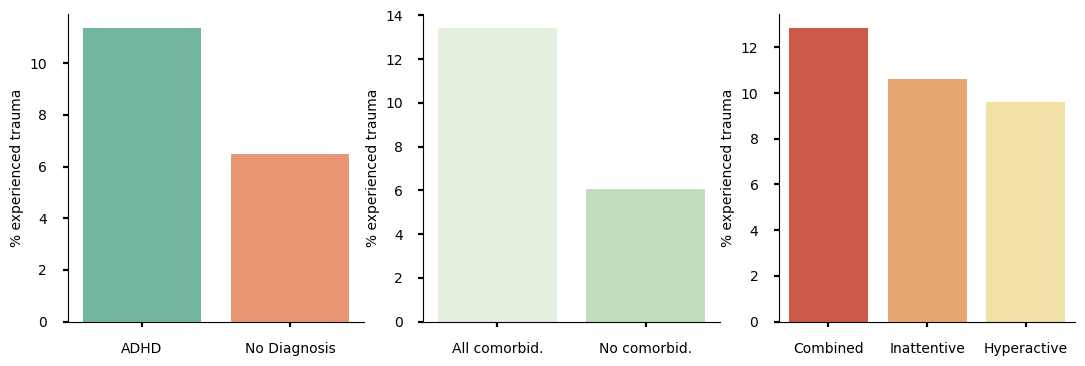

In [12]:
fig = plt.figure(figsize=(13,4))
gs = GridSpec(1, 3, figure=fig)
vis.plotting_style(palette='Set2')

# A # 
dx = 'DX_ADHD'
dx_to_include  = ['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis']
# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )
df['DX_ADHD'] = df['DX_ADHD'].str.extract('(ADHD|No Diagnosis)')

# calculate % people who experienced trauma
df_trauma = get_col_perc(df, groupby=[dx], col='PreInt_TxHx,trauma')

ax = fig.add_subplot(gs[0, 0])
vis.barplot(x='DX_ADHD',
        y='scores',
        xticklabels=['ADHD', 'No Diagnosis'],
        ylim=None, 
        ylabel='% experienced trauma',
        data=df_trauma, 
        ax=ax)

# B # 
dx = 'DX_ADHD'
dx_to_include  = ['ADHD (all comorbid.)', 'ADHD (no comorbid.)']
# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )

# calculate % people who experienced trauma
df_trauma = get_col_perc(df, groupby=[dx], col='PreInt_TxHx,trauma')

vis.plotting_style(palette='Greens')
ax = fig.add_subplot(gs[0, 1])
vis.barplot(x='DX_ADHD',
        y='scores',
        xticklabels=['All comorbid.', 'No comorbid.'],
        ylim=None, 
        ylabel='% experienced trauma',
        data=df_trauma, 
        ax=ax)

# C # 
dx = 'DX_Subtype_Name'
dx_to_include  = ['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)']

# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )

# calculate % people who experienced trauma
df_trauma = get_col_perc(df, groupby=['DX_Subtype_Name'], col='PreInt_TxHx,trauma')

vis.plotting_style(palette='RdYlGn')
ax = fig.add_subplot(gs[0, 2])
vis.barplot(x='DX_Subtype_Name',
        y='scores',
        xticklabels=['Combined', 'Inattentive', 'Hyperactive'],
        order=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
        ylim=None, 
        ylabel='% experienced trauma',
        data=df_trauma, 
        ax=ax)

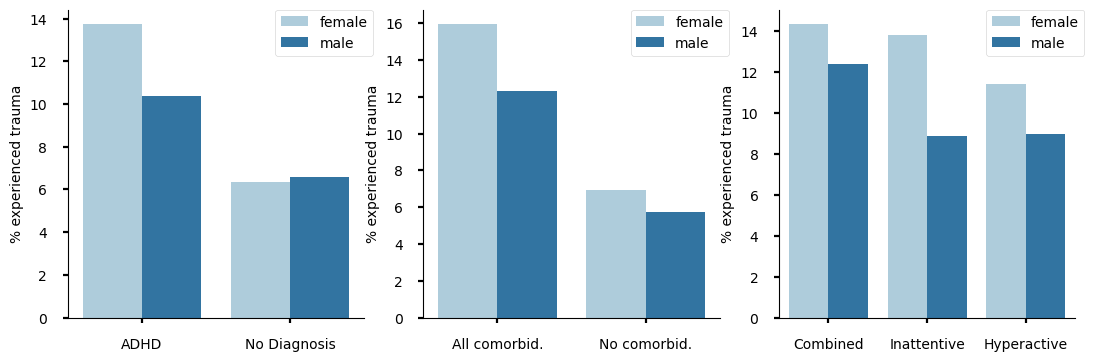

In [55]:
fig = plt.figure(figsize=(13,4))
gs = GridSpec(1, 3, figure=fig)
vis.plotting_style(palette='Paired')

# A # 
dx = 'DX_ADHD'
dx_to_include  = ['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis']
# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )
df['DX_ADHD'] = df['DX_ADHD'].str.extract('(ADHD|No Diagnosis)')

# calculate % people who experienced trauma
df_trauma = get_col_perc(df, groupby=[dx, 'Sex'], col='PreInt_TxHx,trauma')

ax = fig.add_subplot(gs[0, 0])
vis.barplot(x='DX_ADHD',
        y='scores',
        hue='Sex',
        ylim=None, 
        ylabel='% experienced trauma',
        data=df_trauma, 
        ax=ax)
ax.get_legend().set_bbox_to_anchor((.7, 1))


# B # 
dx = 'DX_ADHD'
dx_to_include  = ['ADHD (all comorbid.)', 'ADHD (no comorbid.)']
# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )

# calculate % people who experienced trauma
df_trauma = get_col_perc(df, groupby=[dx, 'Sex'], col='PreInt_TxHx,trauma')

ax = fig.add_subplot(gs[0, 1])
vis.barplot(x='DX_ADHD',
        y='scores',
        hue='Sex',
        xticklabels=['All comorbid.', 'No comorbid.'],
        ylim=None, 
        ylabel='% experienced trauma',
        data=df_trauma, 
        ax=ax)
ax.get_legend().set_bbox_to_anchor((.7, 1))

# C # 
dx = 'DX_Subtype_Name'
dx_to_include  = ['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)']

# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )

# calculate % people who experienced trauma
df_trauma = get_col_perc(df, groupby=['DX_Subtype_Name', 'Sex'], col='PreInt_TxHx,trauma')

ax = fig.add_subplot(gs[0, 2])
vis.barplot(x='DX_Subtype_Name',
        y='scores',
        hue='Sex',
        xticklabels=['Combined', 'Inattentive', 'Hyperactive'],
        order=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
        ylim=None, 
        ylabel='% experienced trauma',
        data=df_trauma, 
        # legend=False,
        ax=ax)
ax.get_legend().set_bbox_to_anchor((.7, 1))

<Axes: ylabel='% experienced trauma'>

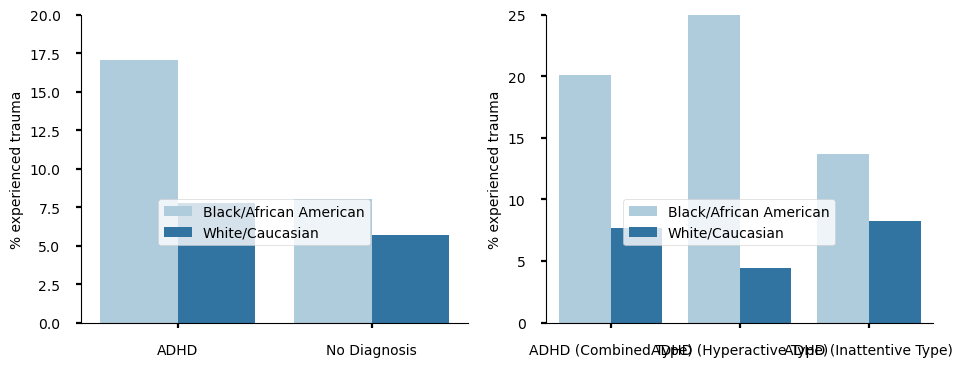

In [12]:
fig = plt.figure(figsize=(11,4))
gs = GridSpec(1, 2, figure=fig)
vis.plotting_style(palette='Paired')

# A # 
dx = 'DX_ADHD'
dx_to_include  = ['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis']

# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )
df['DX_ADHD_binary'] = df['DX_ADHD'].str.extract('(ADHD|No Diagnosis)')

# calculate % people who experienced trauma
df_trauma = get_col_perc(df, groupby=['DX_ADHD_binary',  'Race'], col='PreInt_TxHx,trauma')
df_trauma = df_trauma[df_trauma['Race'].isin(['White/Caucasian', 'Black/African American'])] # 'Two or more races'

# A # 
ax = fig.add_subplot(gs[0, 0])
vis.barplot(
        x='DX_ADHD_binary',
        y='scores',
        hue='Race',
        ylim=[0,20], 
        ylabel='% experienced trauma',
        legend=True,
        # xticklabels=['Black', 'White'], # 'Two or more',
        data=df_trauma,
        ax=ax)

# B # 
dx = 'DX_Subtype_Name'
dx_to_include  = ['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)']

# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )

# calculate % people who experienced trauma
df_trauma = get_col_perc(df, groupby=[dx,  'Race'], col='PreInt_TxHx,trauma')
df_trauma = df_trauma[df_trauma['Race'].isin(['White/Caucasian', 'Black/African American'])] # 'Two or more races'
ax = fig.add_subplot(gs[0, 1])
vis.barplot(
        x=dx,
        y='scores',
        hue='Race',
        ylim=[0,25], 
        ylabel='% experienced trauma',
        legend=True,
        xticklabels=['Combined', 'Inattentive', 'Hyperactive'], # 'Two or more',
        data=df_trauma,
        ax=ax)

Text(0.5, 1.0, 'No Diagnosis')

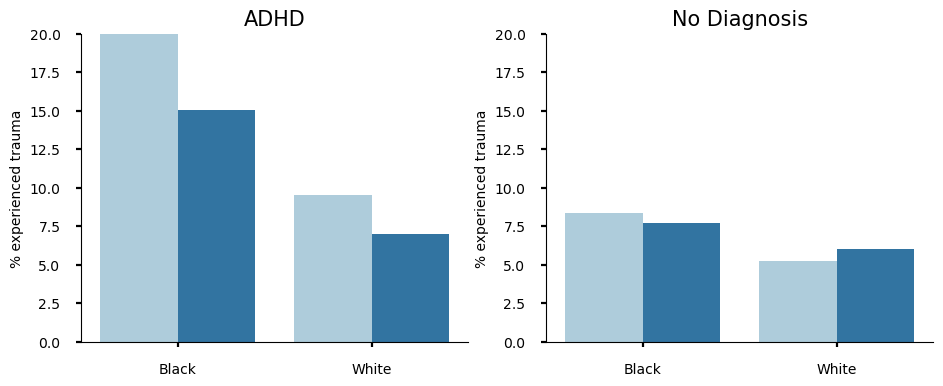

In [7]:
fig = plt.figure(figsize=(11,4))
gs = GridSpec(1, 2, figure=fig)
vis.plotting_style(palette='Paired')

# A # 
dx = 'DX_ADHD'
dx_to_include  = ['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis']

# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )
df['DX_ADHD_binary'] = df['DX_ADHD'].str.extract('(ADHD|No Diagnosis)')

# calculate % people who experienced trauma
df_trauma = get_col_perc(df, groupby=['DX_ADHD_binary', 'Sex', 'Race'], col='PreInt_TxHx,trauma')
df_trauma = df_trauma[df_trauma['Race'].isin(['White/Caucasian', 'Black/African American'])] # 'Two or more races'

# A # 
ax = fig.add_subplot(gs[0, 0])
vis.barplot(
        x='Race',
        y='scores',
        hue='Sex',
        ylim=[0,20], 
        ylabel='% experienced trauma',
        legend=False,
        xticklabels=['Black', 'White'], # 'Two or more',
        data=df_trauma[df_trauma['DX_ADHD_binary']=='ADHD'], 
        ax=ax)
plt.title('ADHD')

# B # 
ax = fig.add_subplot(gs[0, 1])
vis.barplot(
        x='Race',
        y='scores',
        hue='Sex',
        ylim=[0,20], 
        ylabel='% experienced trauma',
        legend=False,
        xticklabels=['Black','White'], #  'Two or more', 
        data=df_trauma[df_trauma['DX_ADHD_binary']=='No Diagnosis'], 
        ax=ax)
plt.title('No Diagnosis')


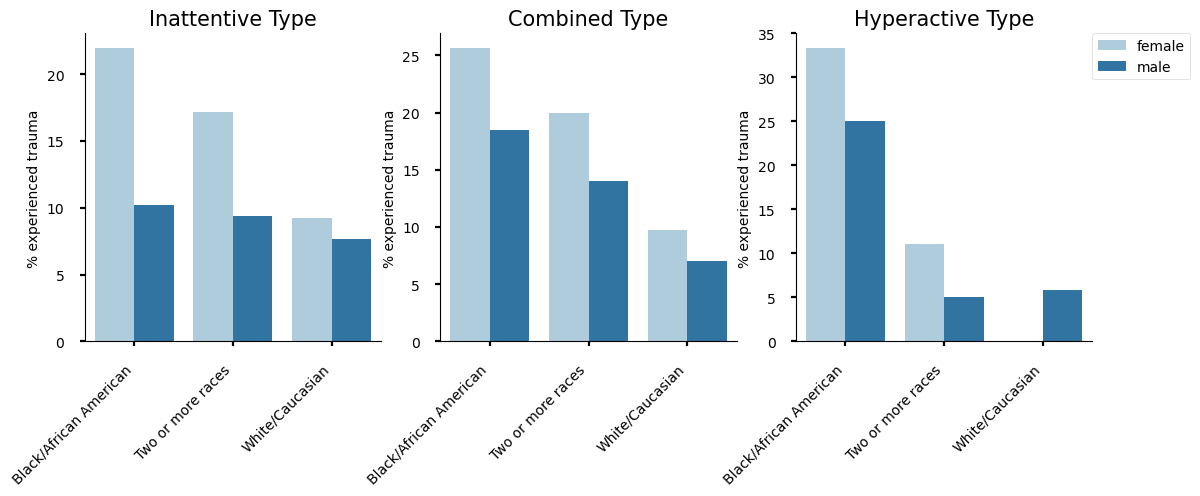

In [59]:
fig = plt.figure(figsize=(13,4))
gs = GridSpec(1, 3, figure=fig)
vis.plotting_style(palette='Paired')

# A # 
dx = 'DX_Subtype_Name'
dx_to_include  = ['ADHD (Inattentive Type)', 'ADHD (Combined Type)', 'ADHD (Hyperactive Type)']

# get data
df = get_data(
        measure='PreInt_TxHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=dx_to_include
        )

# calculate % people who experienced trauma
df_trauma = get_col_perc(df, groupby=[dx, 'Sex', 'Race'], col='PreInt_TxHx,trauma')
df_trauma = df_trauma[df_trauma['Race'].isin(['White/Caucasian', 'Black/African American', 'Two or more races'])]

ax = fig.add_subplot(gs[0, 0])
vis.barplot(
        x='Race',
        y='scores',
        hue='Sex',
        ylim=None, 
        ylabel='% experienced trauma',
        legend=False,
        data=df_trauma[df_trauma['DX_Subtype_Name']=='ADHD (Inattentive Type)'], 
        ax=ax)
plt.title('Inattentive Type')
plt.xticks(rotation=45, ha='right')

# B 
ax = fig.add_subplot(gs[0, 1])
vis.barplot(
        x='Race',
        y='scores',
        hue='Sex',
        ylim=None, 
        ylabel='% experienced trauma',
        legend=False,
        data=df_trauma[df_trauma['DX_Subtype_Name']=='ADHD (Combined Type)'], 
        ax=ax)
plt.title('Combined Type')
plt.xticks(rotation=45, ha='right')

# C 
ax = fig.add_subplot(gs[0, 2])
vis.barplot(
        x='Race',
        y='scores',
        hue='Sex',
        ylim=None, 
        ylabel='% experienced trauma',
        data=df_trauma[df_trauma['DX_Subtype_Name']=='ADHD (Hyperactive Type)'], 
        ax=ax)
plt.title('Hyperactive Type')
plt.xticks(rotation=45, ha='right')
ax.get_legend().set_bbox_to_anchor((1, 1))

### % attempting suicide

<Figure size 900x400 with 0 Axes>

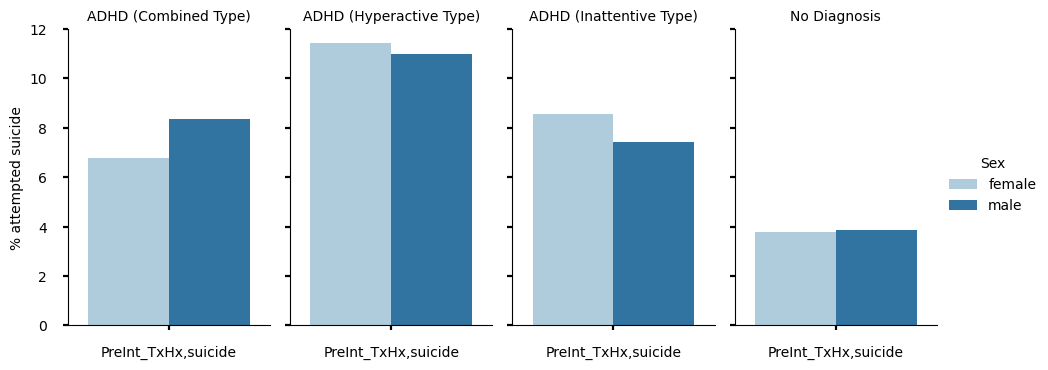

In [123]:

# calculate % people who are currently taking a medication
df_attempt = get_col_perc(df, groupby=['DX_Subtype_Name', 'Sex'], col='PreInt_TxHx,suicide')

vis.plotting_style()
fig = plt.figure(figsize=(9,4))
gs = GridSpec(1, 2, figure=fig)

g = plot_data(df=df_attempt, col=dx)
g.set_axis_labels("", "% attempted suicide")

### Parental Profile of children with ADHD

what % of mothers and fathers have an ADHD diagnosis? or some other psychiatric diagnosis?

In [59]:
## FUNCTIONS ## 

def _get_parent_dx(df, groupby=['DX_Subtype_Name', 'Sex']):
    df_dx_all = pd.DataFrame()
    for parent, p in zip(['Mother', 'Father'], ['m', 'f']):
        df_dx = df.groupby(groupby) \
                .apply(lambda x: x[f'PreInt_FamHx_RDC,{p}dx'] \
                    .value_counts()) \
                            .reset_index(name='count') \
                                .rename(columns={'level_1': 'Parent_DX', 'level_2': 'Parent_DX', 'level_3': 'Parent_DX'})
        df_dx['Parent'] = parent
        df_dx_all = pd.concat([df_dx_all, df_dx], axis=0)
        
    return df_dx_all.reset_index(drop=True)

def list_parent_dx(df):
    df_parent_dx = _get_parent_dx(df)
    return df_parent_dx['Parent_DX'].unique()

def get_parent_data_to_plot(df, dx=['ADHD'], groupby=['DX_Subtype_Name', 'Sex'], separate_parent_dx=True):

    # get parent dx
    df_parent_dx = _get_parent_dx(df, groupby=groupby)

    # get data on parents who have dx of ADHD
    groupby_all = []
    if separate_parent_dx:
        groupby_all = ['Parent']
    groupby_all.extend(groupby)
    df_parent_adhd = df_parent_dx[df_parent_dx['Parent_DX'] \
                                    .isin(dx)] \
                                        .groupby(groupby_all) \
                                            .apply(lambda x: x['count'].sum()) \
                                                .reset_index(name='dx_count')
    # get overall count of subtypes across sex  
    df_dx_sex_count = df.groupby(groupby).size().reset_index(name='total_count')

    # get percentage of subtypes across sex
    df_parent_perc = df_parent_adhd.merge(df_dx_sex_count, on=groupby) \
        .groupby(groupby_all) \
            .apply(lambda x: x['dx_count'] / x['total_count'] * 100) \
                .reset_index(name='perc')
    
    return df_parent_perc

def get_parent_dx(
                df=None,
                dx='DX_Subtype_Name', 
                dx_to_include=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)', 'No Diagnosis'],
                separate_parent_dx=True, 
                groupby=['DX_Subtype_Name']
                ):
        if df is None:
            # get data
            df = get_data(
                    measure='PreInt_FamHx_RDC',
                    assessment='Parent',
                    dx=dx,
                    dx_to_include=dx_to_include,
                    )

        # get all disorders (excluding no diagnosis etc.)
        all_dx = list_parent_dx(df)
        bool = [dx not in ['No Diagnosis', 'Other', 'Other Diagnosis', '0No Diagnosis', 'No Response'] for dx in all_dx]

        # get all dx
        dx_dict = {
                'ADHD': ['ADHD', 'ADHD Inattentive'],
                'Mood Disorder': ['Major Depressive Disorder', 'Major Depression', 'depression', 
                'Depression', 'Other Diagnosis: Clinical Depression',
                'Bipolar II', 'Bipolar (Type Unknown)'],
                'Anxiety Disorder': ['Generalized Anxiety', 'Genarlized Anxiety', 
                'Anxiety', 'Other Anxiety', 'Generalized Anxiety', 
                'Social Phobia', 'Panic Disorder', 'OCD'],
                'Personality Disorder': ['Borderline Personality Disorder', 'Other Personality Disorder'],
                'All DX': all_dx[bool]
                }

        df_parent_dx_all = pd.DataFrame()
        for k, v in dx_dict.items():
                df_parent_dx = get_parent_data_to_plot(df, dx=v, groupby=groupby, separate_parent_dx=separate_parent_dx)
                df_parent_dx['Parent_DX_Cat'] = k
                df_parent_dx_all = pd.concat([df_parent_dx_all, df_parent_dx], axis=0)
        

        return df_parent_dx_all


<Axes: ylabel='% of parents who have a psych dx'>

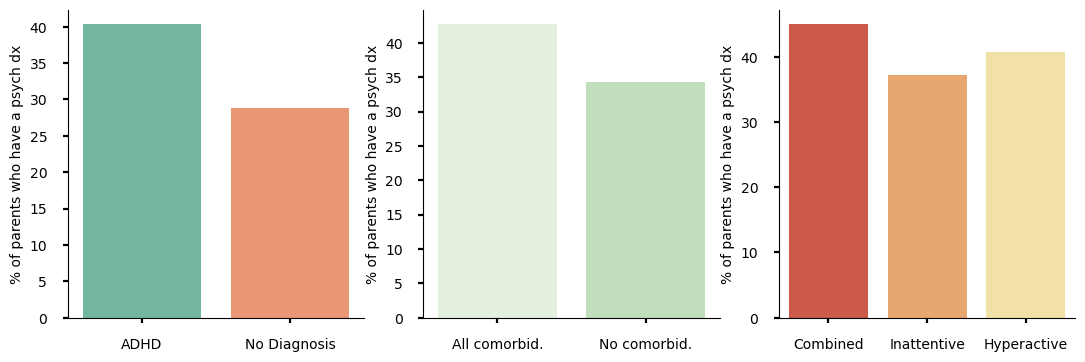

In [38]:

fig = plt.figure(figsize=(13,4))
gs = GridSpec(1, 3, figure=fig)

# A # 
vis.plotting_style(palette='Set2')

df = get_data(
        measure='PreInt_FamHx_RDC',
        assessment='Parent',
        dx='DX_ADHD',
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis'],
        )
df['DX_ADHD'] = df['DX_ADHD'].str.extract('(ADHD|No Diagnosis)')

df_parent_dx_all = get_parent_dx(
        df,
        dx='DX_ADHD', 
        dx_to_include=['ADHD', 'No Diagnosis'],
        separate_parent_dx=False,
        groupby=['DX_ADHD']
        )

ax = fig.add_subplot(gs[0, 0])
df1 = df_parent_dx_all[df_parent_dx_all['Parent_DX_Cat']=='All DX']
vis.barplot(
        x='DX_ADHD',
        y='perc',
        # hue='Parent',
        ylim=None, 
        ylabel='% of parents who have a psych dx',
        data=df1, 
        ax=ax
        )

# A # 
vis.plotting_style(palette='Greens')
df_parent_dx_all = get_parent_dx(
        dx='DX_ADHD', 
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis'],
        separate_parent_dx=False,
        groupby=['DX_ADHD']
        )

ax = fig.add_subplot(gs[0, 1])
df1 = df_parent_dx_all[df_parent_dx_all['Parent_DX_Cat']=='All DX']
vis.barplot(
        x='DX_ADHD',
        y='perc',
        # hue='Parent',
        xticklabels=['All comorbid.', 'No comorbid.'],
        order=['ADHD (all comorbid.)', 'ADHD (no comorbid.)'],
        ylim=None, 
        ylabel='% of parents who have a psych dx',
        data=df1, 
        ax=ax
        )

# B # 
vis.plotting_style(palette='RdYlGn')
ax = fig.add_subplot(gs[0, 2])
df_parent_dx_subtype = get_parent_dx(dx='DX_Subtype_Name', 
                dx_to_include=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
                separate_parent_dx=False,
                groupby=['DX_Subtype_Name'])

df1 = df_parent_dx_subtype[df_parent_dx_subtype['Parent_DX_Cat']=='All DX']
vis.barplot(x='DX_Subtype_Name',
        y='perc',
        # hue='Parent',
        xticklabels=['Combined', 'Inattentive', 'Hyperactive'],
        order=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
        ylim=None, 
        ylabel='% of parents who have a psych dx',
        legend=False,
        data=df1, 
        ax=ax)

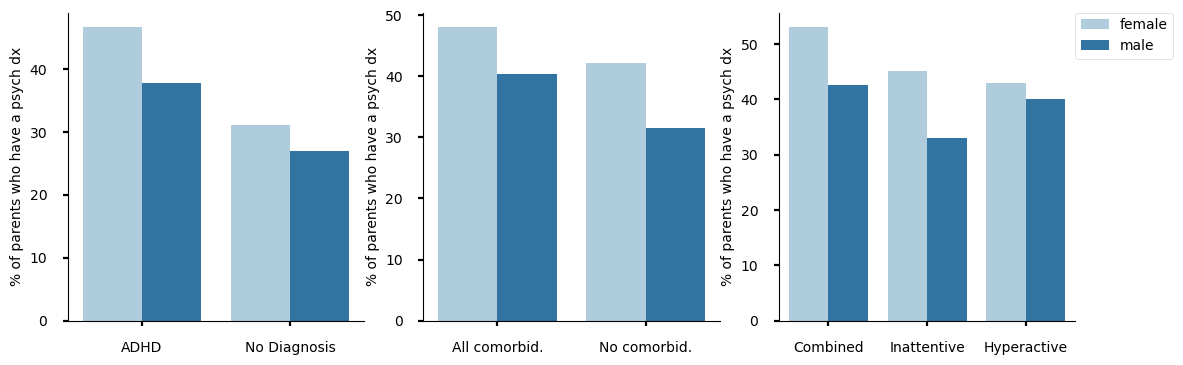

In [80]:

fig = plt.figure(figsize=(13,4))
gs = GridSpec(1, 3, figure=fig)

# A # 
vis.plotting_style(palette='Paired')

df = get_data(
        measure='PreInt_FamHx_RDC',
        assessment='Parent',
        dx='DX_ADHD',
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis'],
        )
df['DX_ADHD'] = df['DX_ADHD'].str.extract('(ADHD|No Diagnosis)')

df_parent_dx_all = get_parent_dx(
        df,
        dx='DX_ADHD', 
        dx_to_include=['ADHD', 'No Diagnosis'],
        separate_parent_dx=False,
        groupby=['DX_ADHD', 'Sex']
        )

ax = fig.add_subplot(gs[0, 0])
df1 = df_parent_dx_all[df_parent_dx_all['Parent_DX_Cat']=='All DX']
vis.barplot(
        x='DX_ADHD',
        y='perc',
        hue='Sex',
        ylim=None, 
        legend=False,
        ylabel='% of parents who have a psych dx',
        data=df1, 
        ax=ax
        )

# A # 
df_parent_dx_all = get_parent_dx(
        dx='DX_ADHD', 
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis'],
        separate_parent_dx=False,
        groupby=['DX_ADHD', 'Sex']
        )

ax = fig.add_subplot(gs[0, 1])
df1 = df_parent_dx_all[df_parent_dx_all['Parent_DX_Cat']=='All DX']
vis.barplot(
        x='DX_ADHD',
        y='perc',
        hue='Sex',
        xticklabels=['All comorbid.', 'No comorbid.'],
        order=['ADHD (all comorbid.)', 'ADHD (no comorbid.)'],
        ylim=None, 
        legend=False,
        ylabel='% of parents who have a psych dx',
        data=df1, 
        ax=ax
        )

# B # 
ax = fig.add_subplot(gs[0, 2])
df_parent_dx_subtype = get_parent_dx(dx='DX_Subtype_Name', 
                dx_to_include=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
                separate_parent_dx=False,
                groupby=['DX_Subtype_Name', 'Sex'])

df1 = df_parent_dx_subtype[df_parent_dx_subtype['Parent_DX_Cat']=='All DX']
vis.barplot(x='DX_Subtype_Name',
        y='perc',
        hue='Sex',
        xticklabels=['Combined', 'Inattentive', 'Hyperactive'],
        order=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
        ylim=None, 
        ylabel='% of parents who have a psych dx',
        # legend=False,
        data=df1, 
        ax=ax)
ax.get_legend().set_bbox_to_anchor((1, 1))

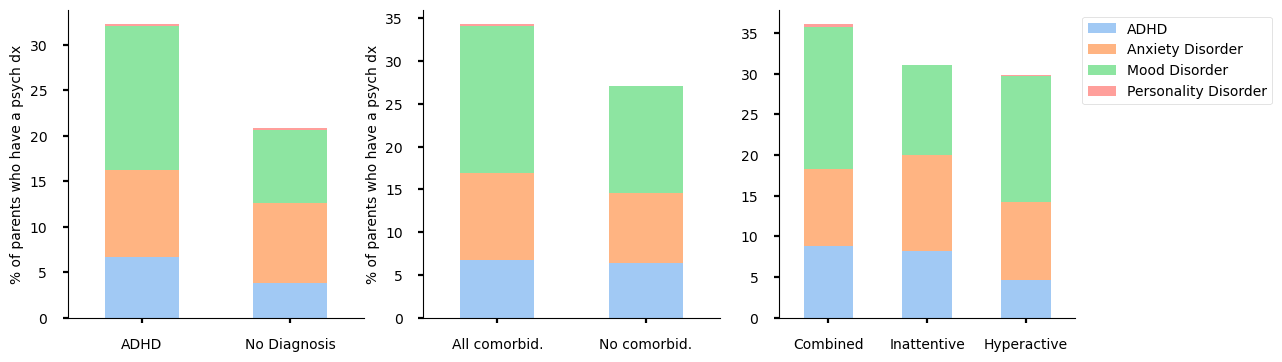

In [69]:
fig = plt.figure(figsize=(13,4))
gs = GridSpec(1, 3, figure=fig)
vis.plotting_style(palette='pastel')

# A #
df = get_data(
        measure='PreInt_FamHx_RDC',
        assessment='Parent',
        dx='DX_ADHD',
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis'],
        )
df['DX_ADHD'] = df['DX_ADHD'].str.extract('(ADHD|No Diagnosis)')

df_parent_dx_all = get_parent_dx(
        df,
        dx='DX_ADHD', 
        dx_to_include=['ADHD', 'No Diagnosis'],
        separate_parent_dx=False,
        groupby=['DX_ADHD']
        )
ax = fig.add_subplot(gs[0, 0])
df_perc_pivot = df_parent_dx_all[df_parent_dx_all['Parent_DX_Cat']!='All DX'] \
    .pivot(index='DX_ADHD', columns='Parent_DX_Cat', values='perc')

df_perc_pivot.plot(kind='bar', stacked=True, ax=ax)
ax.get_legend().remove()
ax.set_xlabel('')
ax.set_ylabel('% of parents who have a psych dx')
plt.xticks(rotation=0, fontsize=10);

# B # 
df_parent_dx_all = get_parent_dx(
        dx='DX_ADHD', 
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis'],
        groupby=['DX_ADHD'],
        separate_parent_dx=False
        )

ax = fig.add_subplot(gs[0, 1])
df_perc_pivot = df_parent_dx_all[(df_parent_dx_all['Parent_DX_Cat']!='All DX') & (df_parent_dx_all['DX_ADHD']!='No Diagnosis')] \
    .pivot(index='DX_ADHD', columns='Parent_DX_Cat', values='perc')

df_perc_pivot.plot(kind='bar', stacked=True, ax=ax)
ax.get_legend().remove()
ax.set_xlabel('')
ax.set_ylabel('% of parents who have a psych dx')
plt.xticks(rotation=0, fontsize=10);
ax.xaxis.set_ticklabels(['All comorbid.', 'No comorbid.'])

# B #
df_parent_dx_all = get_parent_dx(
        dx='DX_Subtype_Name', 
        dx_to_include=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
        groupby=['DX_Subtype_Name'],
        separate_parent_dx=False
        )

ax = fig.add_subplot(gs[0, 2])
df_perc_pivot = df_parent_dx_all[df_parent_dx_all['Parent_DX_Cat']!='All DX'] \
    .pivot(index='DX_Subtype_Name', columns='Parent_DX_Cat', values='perc')

df_perc_pivot.plot(kind='bar', stacked=True, ax=ax)
ax.get_legend().set_title('')
ax.set_xlabel('')
plt.xticks(rotation=0, fontsize=10);
ax.xaxis.set_ticklabels(['Combined', 'Inattentive', 'Hyperactive']);
ax.get_legend().set_bbox_to_anchor((1, 1))

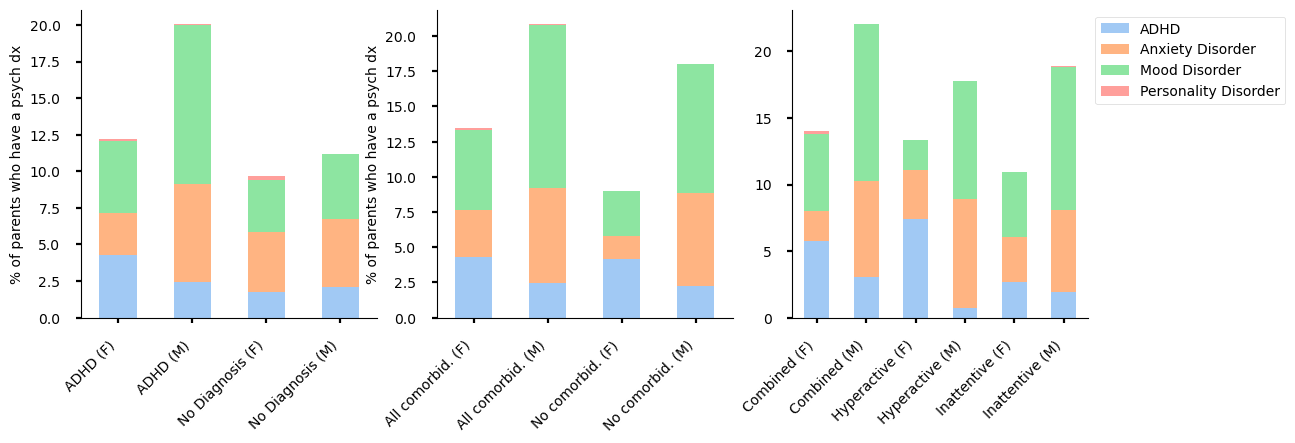

In [72]:
fig = plt.figure(figsize=(13,4))
gs = GridSpec(1, 3, figure=fig)
vis.plotting_style(palette='pastel')

# A # 
df = get_data(
        measure='PreInt_FamHx_RDC',
        assessment='Parent',
        dx='DX_ADHD',
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis'],
        )
df['DX_ADHD'] = df['DX_ADHD'].str.extract('(ADHD|No Diagnosis)')

df_parent_dx_all = get_parent_dx(
        df,
        dx='DX_ADHD', 
        dx_to_include=['ADHD', 'No Diagnosis'],
        separate_parent_dx=True,
        groupby=['DX_ADHD']
        )

ax = fig.add_subplot(gs[0, 0])
df_parent_dx_all['DX_ADHD_Parent'] = df_parent_dx_all['DX_ADHD'] + ' ' + df_parent_dx_all['Parent']
df_parent_dx_all.drop(['DX_ADHD', 'Parent'], axis=1, inplace=True)

df_perc_pivot = df_parent_dx_all[df_parent_dx_all['Parent_DX_Cat']!='All DX'] \
    .pivot(index='DX_ADHD_Parent', columns='Parent_DX_Cat', values='perc')

df_perc_pivot.plot(kind='bar', stacked=True, ax=ax)
ax.get_legend().remove()
ax.set_xlabel('')
ax.set_ylabel('% of parents who have a psych dx')
plt.xticks(rotation=45, fontsize=10, ha='right');
ax.xaxis.set_ticklabels(['ADHD (F)', 'ADHD (M)', 'No Diagnosis (F)', 'No Diagnosis (M)'])

# B # 
df_parent_dx_all = get_parent_dx(
        dx='DX_ADHD', 
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)'],
        separate_parent_dx=True,
         groupby=['DX_ADHD']
        )

ax = fig.add_subplot(gs[0, 1])
df_parent_dx_all['DX_ADHD_Parent'] = df_parent_dx_all['DX_ADHD'] + ' ' + df_parent_dx_all['Parent']
df_parent_dx_all.drop(['DX_ADHD', 'Parent'], axis=1, inplace=True)

df_perc_pivot = df_parent_dx_all[df_parent_dx_all['Parent_DX_Cat']!='All DX'] \
    .pivot(index='DX_ADHD_Parent', columns='Parent_DX_Cat', values='perc')

df_perc_pivot.plot(kind='bar', stacked=True, ax=ax)
ax.get_legend().remove()
ax.set_xlabel('')
ax.set_ylabel('% of parents who have a psych dx')
plt.xticks(rotation=45, fontsize=10, ha='right');
ax.xaxis.set_ticklabels(['All comorbid. (F)', 'All comorbid. (M)', 'No comorbid. (F)', 'No comorbid. (M)'])

# B #
df_parent_dx_all = get_parent_dx(
        dx='DX_Subtype_Name', 
        dx_to_include=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
        separate_parent_dx=True,
        groupby=['DX_Subtype_Name']
        )

ax = fig.add_subplot(gs[0, 2])
df_parent_dx_all['DX_Subtype_Name_Parent'] = df_parent_dx_all['DX_Subtype_Name'] + ' ' + df_parent_dx_all['Parent']
df_parent_dx_all.drop(['DX_Subtype_Name', 'Parent'], axis=1, inplace=True)
df_perc_pivot = df_parent_dx_all[df_parent_dx_all['Parent_DX_Cat']!='All DX'] \
    .pivot(index='DX_Subtype_Name_Parent', columns='Parent_DX_Cat', values='perc')

df_perc_pivot.plot(kind='bar', stacked=True, ax=ax)
ax.get_legend().set_title('')
ax.set_xlabel('')
plt.xticks(rotation=45, fontsize=10,ha='right');
ax.xaxis.set_ticklabels(['Combined (F)', 'Combined (M)', 'Hyperactive (F)', 'Hyperactive (M)', 'Inattentive (F)', 'Inattentive (M)']);
ax.get_legend().set_bbox_to_anchor((1, 1));

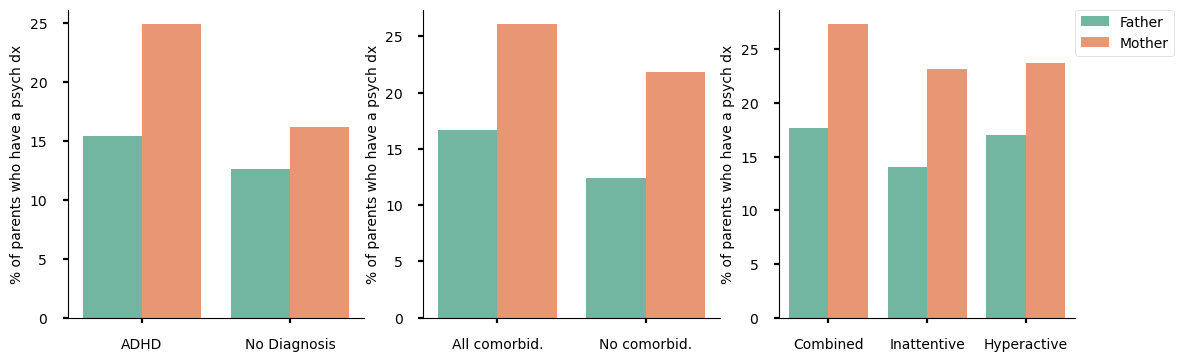

In [76]:

fig = plt.figure(figsize=(13,4))
gs = GridSpec(1, 3, figure=fig)
vis.plotting_style(palette='Set2')

# A # 
df = get_data(
        measure='PreInt_FamHx_RDC',
        assessment='Parent',
        dx='DX_ADHD',
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis'],
        )
df['DX_ADHD'] = df['DX_ADHD'].str.extract('(ADHD|No Diagnosis)')

df_parent_dx_all = get_parent_dx(
        df,
        dx='DX_ADHD', 
        dx_to_include=['ADHD', 'No Diagnosis'],
        separate_parent_dx=True,
        groupby=['DX_ADHD']
        )

ax = fig.add_subplot(gs[0, 0])
df1 = df_parent_dx_all[df_parent_dx_all['Parent_DX_Cat']=='All DX']
vis.barplot(
        x='DX_ADHD',
        y='perc',
        hue='Parent',
        ylim=None, 
        legend=False,
        ylabel='% of parents who have a psych dx',
        data=df1, 
        ax=ax
        )

# B # 
df_parent_dx_all = get_parent_dx(
        dx='DX_ADHD', 
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)'],
        groupby=['DX_ADHD']
        )

vis.plotting_style(palette='Set2')
ax = fig.add_subplot(gs[0, 1])
df1 = df_parent_dx_all[df_parent_dx_all['Parent_DX_Cat']=='All DX']
vis.barplot(
        x='DX_ADHD',
        y='perc',
        hue='Parent',
        xticklabels=['All comorbid.', 'No comorbid.'],
        order=['ADHD (all comorbid.)', 'ADHD (no comorbid.)'],
        ylim=None, 
        legend=False,
        ylabel='% of parents who have a psych dx',
        data=df1, 
        ax=ax
        )

# B # 
vis.plotting_style(palette='Set2')
ax = fig.add_subplot(gs[0, 2])
df_parent_dx_subtype = get_parent_dx(dx='DX_Subtype_Name', 
                dx_to_include=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
                groupby=['DX_Subtype_Name'])

df1 = df_parent_dx_subtype[df_parent_dx_subtype['Parent_DX_Cat']=='All DX']
vis.barplot(x='DX_Subtype_Name',
        y='perc',
        hue='Parent',
        xticklabels=['Combined', 'Inattentive', 'Hyperactive'],
        order=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
        ylim=None, 
        ylabel='% of parents who have a psych dx',
        data=df1, 
        ax=ax)
ax.get_legend().set_bbox_to_anchor((1, 1));

### Breakdown by sex

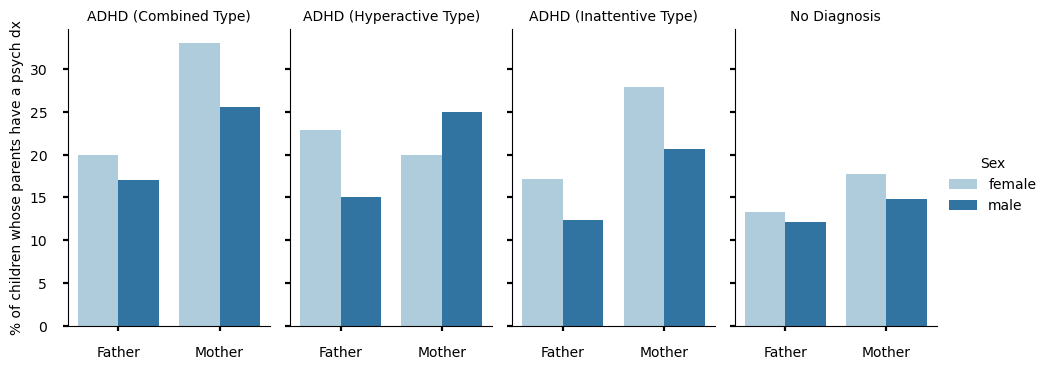

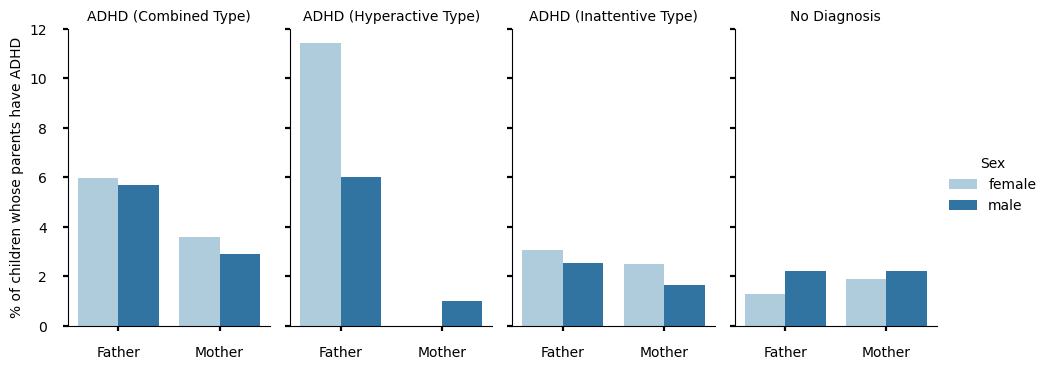

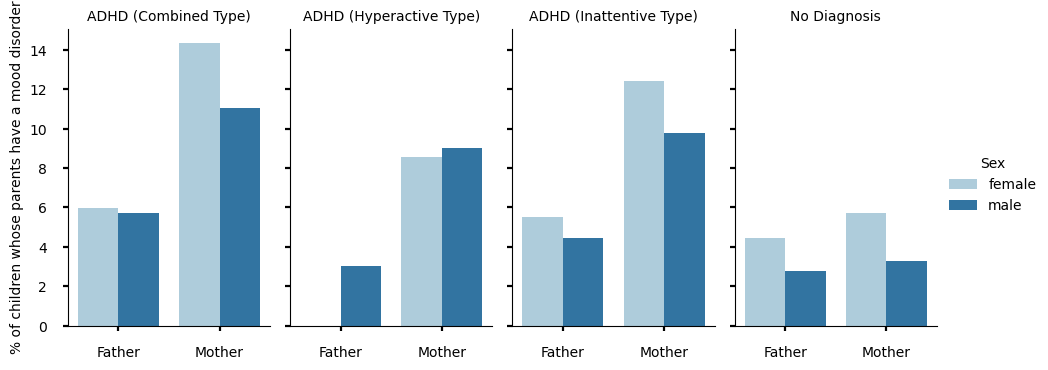

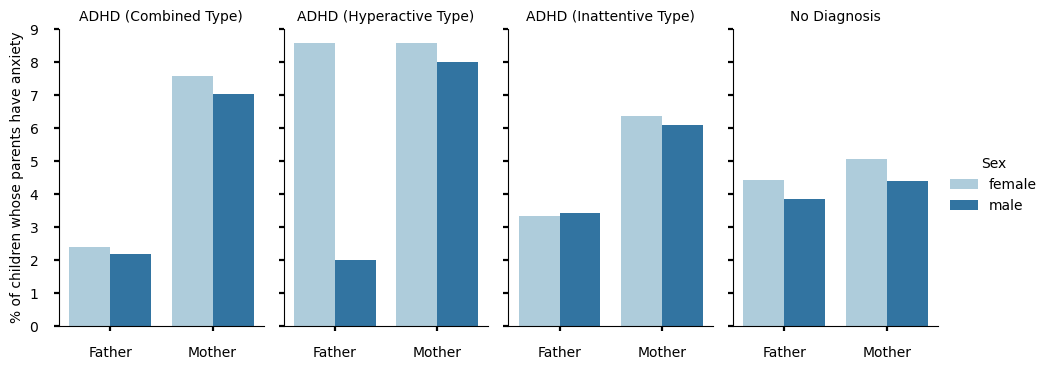

In [31]:
vis.plotting_style(palette='Paired')

df_parent_dx_subtype = get_parent_dx(dx='DX_Subtype_Name', 
                dx_to_include=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)', 'No Diagnosis'],
                groupby=['DX_Subtype_Name', 'Sex'])

df1 = df_parent_dx_subtype[df_parent_dx_subtype['Parent_DX_Cat']=='All DX']
g = plot_data(df1, col='DX_Subtype_Name', x='Parent', y='perc', hue='Sex', kind='bar')
g.set_axis_labels("", "% of children whose parents have a psych dx")

df1 = df_parent_dx_subtype[df_parent_dx_subtype['Parent_DX_Cat']=='ADHD']
g = plot_data(df1, col='DX_Subtype_Name', x='Parent', y='perc', hue='Sex', kind='bar')
g.set_axis_labels("", "% of children whose parents have ADHD")

df1 = df_parent_dx_subtype[df_parent_dx_subtype['Parent_DX_Cat']=='Mood Disorder']
g = plot_data(df1, col='DX_Subtype_Name', x='Parent', y='perc', hue='Sex', kind='bar')
g.set_axis_labels("", "% of children whose parents have a mood disorder")

df1 = df_parent_dx_subtype[df_parent_dx_subtype['Parent_DX_Cat']=='Anxiety Disorder']
g = plot_data(df1, col='DX_Subtype_Name', x='Parent', y='perc', hue='Sex', kind='bar')
g.set_axis_labels("", "% of children whose parents have anxiety")

### Parental Distress

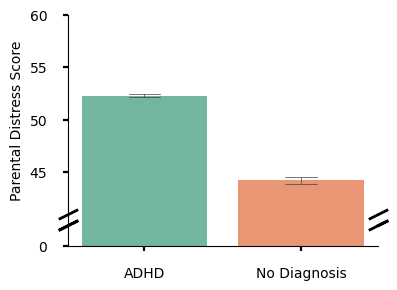

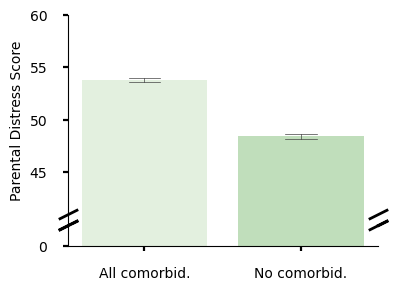

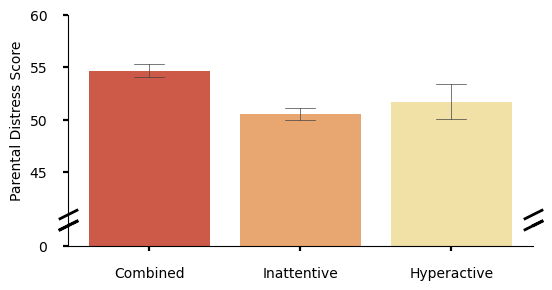

In [82]:
# A # 
df_psi_all = get_data(
        measure='PSI',
        assessment='Parent',
        dx='DX_ADHD',
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis'],
        cols_to_filter=None
        )
df_psi_all['DX_ADHD'] = df_psi_all['DX_ADHD'].str.extract('(ADHD|No Diagnosis)')

vis.plotting_style(palette='Set2')
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(4, 3)

xticklabels = ['ADHD', 'No Diagnosis']
order = xticklabels
ax1 = vis.barplot(x='DX_ADHD', y='PSI,PSI_Total_T', xticklabels=xticklabels, ylim=None, ylabel='Parental Distress Score', data=df_psi_all, order=order,ax=ax1)
ax2 = vis.barplot(x='DX_ADHD', y='PSI,PSI_Total_T',  xticklabels=xticklabels, ylim=None, legend=False, ylabel='', order=order, data=df_psi_all, ax=ax2)

ax1, ax2 = vis.modify_axes(ax1, ax2, ylim_outliers=(40, 60))
vis._draw_cut(ax1, ax2)

# B # 
df_psi_all = get_data(
        measure='PSI',
        assessment='Parent',
        dx='DX_ADHD',
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)'],
        cols_to_filter=None
        )

vis.plotting_style(palette='Greens')
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(4, 3)

xticklabels = ['All comorbid.', 'No comorbid.']
order =['ADHD (all comorbid.)', 'ADHD (no comorbid.)']
ax1 = vis.barplot(x='DX_ADHD', y='PSI,PSI_Total_T', xticklabels=xticklabels, ylim=None, ylabel='Parental Distress Score', data=df_psi_all, order=order,ax=ax1)
ax2 = vis.barplot(x='DX_ADHD', y='PSI,PSI_Total_T',  xticklabels=xticklabels, ylim=None, legend=False, ylabel='', order=order, data=df_psi_all, ax=ax2)

ax1, ax2 = vis.modify_axes(ax1, ax2, ylim_outliers=(40, 60))
vis._draw_cut(ax1, ax2)

# B # 
df_psi_subtype = get_data(
        measure='PSI',
        assessment='Parent',
        dx='DX_Subtype_Name',
        dx_to_include=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
        cols_to_filter=None
        )

vis.plotting_style(palette='RdYlGn')
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(6, 3)

order = ['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)']
xticklabels = ['Combined', 'Inattentive', 'Hyperactive']
ax1 = vis.barplot(x='DX_Subtype_Name', y='PSI,PSI_Total_T', xticklabels=xticklabels, ylim=None, ylabel='Parental Distress Score', order=order, data=df_psi_subtype, ax=ax1)
ax2 = vis.barplot(x='DX_Subtype_Name', y='PSI,PSI_Total_T',  xticklabels=xticklabels, ylim=None, legend=False, ylabel='', order=order, data=df_psi_subtype, ax=ax2)

ax1, ax2 = vis.modify_axes(ax1, ax2, ylim_outliers=(40, 60))
vis._draw_cut(ax1, ax2)

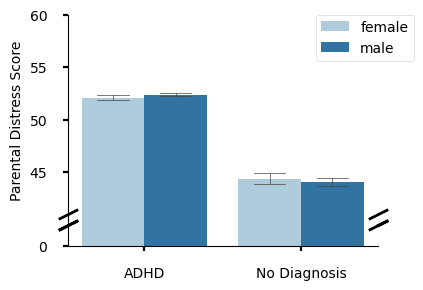

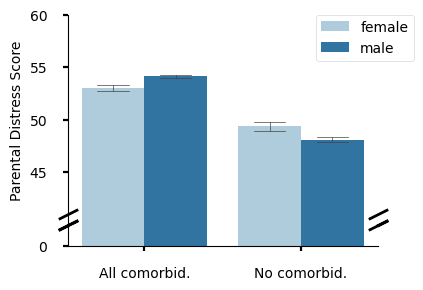

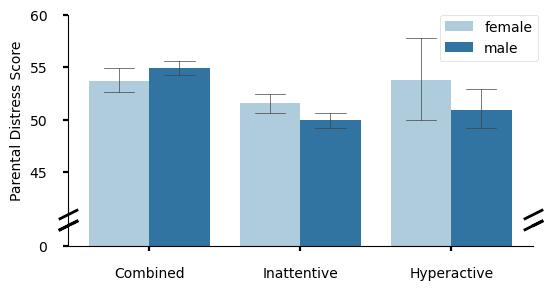

In [85]:
# A # 
df_psi_all = get_data(
        measure='PSI',
        assessment='Parent',
        dx='DX_ADHD',
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis'],
        cols_to_filter=None
        )
df_psi_all['DX_ADHD'] = df_psi_all['DX_ADHD'].str.extract('(ADHD|No Diagnosis)')

vis.plotting_style(palette='Paired')
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(4, 3)

xticklabels = ['ADHD', 'No Diagnosis']
order = xticklabels
ax1 = vis.barplot(x='DX_ADHD', y='PSI,PSI_Total_T', hue='Sex', xticklabels=xticklabels, ylim=None, ylabel='Parental Distress Score', data=df_psi_all, order=order,ax=ax1)
ax2 = vis.barplot(x='DX_ADHD', y='PSI,PSI_Total_T',  hue='Sex', xticklabels=xticklabels, ylim=None, legend=False, ylabel='', order=order, data=df_psi_all, ax=ax2)
ax1.get_legend().set_bbox_to_anchor((.8, 1.0))

ax1, ax2 = vis.modify_axes(ax1, ax2, ylim_outliers=(40, 60))
vis._draw_cut(ax1, ax2)

# B # 
df_psi_all = get_data(
        measure='PSI',
        assessment='Parent',
        dx='DX_ADHD',
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)'],
        cols_to_filter=None
        )

vis.plotting_style(palette='Paired')
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(4, 3)

xticklabels = ['All comorbid.', 'No comorbid.']
order =['ADHD (all comorbid.)', 'ADHD (no comorbid.)']
ax1 = vis.barplot(x='DX_ADHD', y='PSI,PSI_Total_T', hue='Sex', xticklabels=xticklabels, ylim=None, ylabel='Parental Distress Score', data=df_psi_all.sort_values(by='Sex', ascending=True), order=order,ax=ax1)
ax2 = vis.barplot(x='DX_ADHD', y='PSI,PSI_Total_T',  hue='Sex', xticklabels=xticklabels, ylim=None, legend=False, ylabel='', order=order, data=df_psi_all, ax=ax2)
ax1.get_legend().set_bbox_to_anchor((.8, 1.0))

ax1, ax2 = vis.modify_axes(ax1, ax2, ylim_outliers=(40, 60))
vis._draw_cut(ax1, ax2)

# B # 
df_psi_subtype = get_data(
        measure='PSI',
        assessment='Parent',
        dx='DX_Subtype_Name',
        dx_to_include=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
        cols_to_filter=None
        )
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(6, 3)

order = ['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)']
xticklabels = ['Combined', 'Inattentive', 'Hyperactive']
ax1 = vis.barplot(x='DX_Subtype_Name', y='PSI,PSI_Total_T', hue='Sex', xticklabels=xticklabels, ylim=None, ylabel='Parental Distress Score', order=order, data=df_psi_subtype.sort_values(by='Sex', ascending=True), ax=ax1)
ax2 = vis.barplot(x='DX_Subtype_Name', y='PSI,PSI_Total_T',  hue='Sex', xticklabels=xticklabels, ylim=None, legend=False, ylabel='', order=order, data=df_psi_subtype, ax=ax2)
ax1.get_legend().set_bbox_to_anchor((.8, 1.0))

ax1, ax2 = vis.modify_axes(ax1, ax2, ylim_outliers=(40, 60))
vis._draw_cut(ax1, ax2)

### Differences in puberty across subtypes? 

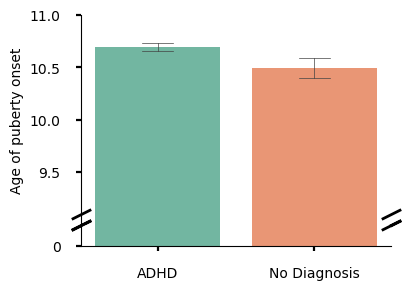

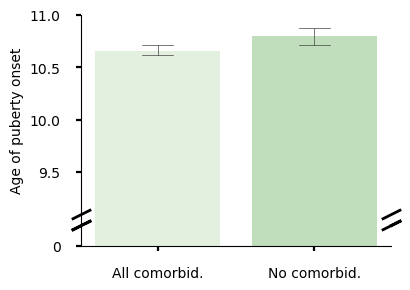

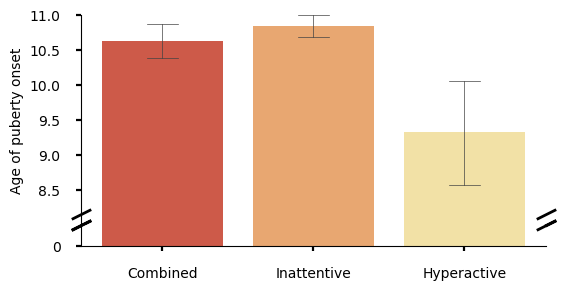

In [87]:
# A # 
df_puberty = get_data(
        measure='PreInt_DevHx',
        assessment='Parent',
        dx='DX_ADHD',
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis'],
        cols_to_filter=None
        )
df_puberty['DX_ADHD'] = df_puberty['DX_ADHD'].str.extract('(ADHD|No Diagnosis)')

vis.plotting_style(palette='Set2')
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(4, 3)

xticklabels = ['ADHD', 'No Diagnosis']
order = xticklabels
ax1 = vis.barplot(x='DX_ADHD', y='PreInt_DevHx,puberty_age', xticklabels=xticklabels, ylim=None, ylabel='Age of puberty onset', data=df_puberty, order=order,ax=ax1)
ax2 = vis.barplot(x='DX_ADHD', y='PreInt_DevHx,puberty_age',  xticklabels=xticklabels, ylim=None, legend=False, ylabel='', order=order, data=df_puberty, ax=ax2)

ax1, ax2 = vis.modify_axes(ax1, ax2, ylim_outliers=(9, 11), ylim_data=(0,1))
vis._draw_cut(ax1, ax2)

# B # 
df_puberty = get_data(
        measure='PreInt_DevHx',
        assessment='Parent',
        dx='DX_ADHD',
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)'],
        cols_to_filter=None
        )

vis.plotting_style(palette='Greens')
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(4, 3)

xticklabels = ['All comorbid.', 'No comorbid.']
order =['ADHD (all comorbid.)', 'ADHD (no comorbid.)']
ax1 = vis.barplot(x='DX_ADHD', y='PreInt_DevHx,puberty_age', xticklabels=xticklabels, ylim=None, ylabel='Age of puberty onset', data=df_puberty, order=order,ax=ax1)
ax2 = vis.barplot(x='DX_ADHD', y='PreInt_DevHx,puberty_age',  xticklabels=xticklabels, ylim=None, legend=False, ylabel='', order=order, data=df_puberty, ax=ax2)

ax1, ax2 = vis.modify_axes(ax1, ax2, ylim_outliers=(9, 11), ylim_data=(0,1))
vis._draw_cut(ax1, ax2)

# B # 
df_puberty = get_data(
        measure='PreInt_DevHx',
        assessment='Parent',
        dx='DX_Subtype_Name',
        dx_to_include=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
        cols_to_filter=None
        )

vis.plotting_style(palette='RdYlGn')
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(6, 3)

order = ['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)']
xticklabels = ['Combined', 'Inattentive', 'Hyperactive']
ax1 = vis.barplot(x='DX_Subtype_Name', y='PreInt_DevHx,puberty_age', xticklabels=xticklabels, ylim=None, ylabel='Age of puberty onset', order=order, data=df_puberty, ax=ax1)
ax2 = vis.barplot(x='DX_Subtype_Name', y='PreInt_DevHx,puberty_age',  xticklabels=xticklabels, ylim=None, legend=False, ylabel='', order=order, data=df_puberty, ax=ax2)

ax1, ax2 = vis.modify_axes(ax1, ax2, ylim_outliers=(8, 11), ylim_data=(0,1))
vis._draw_cut(ax1, ax2)

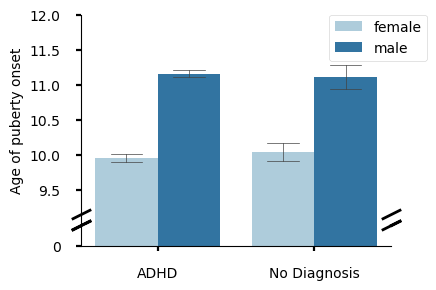

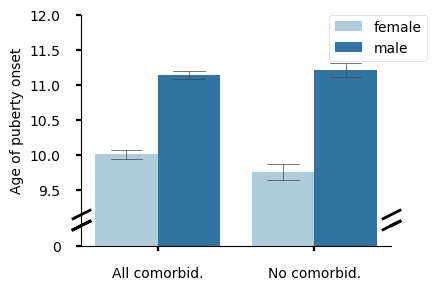

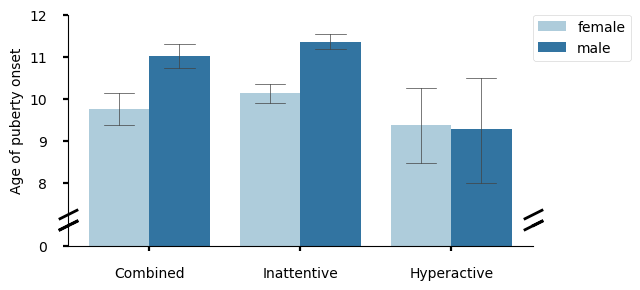

In [90]:
# A # 
df_puberty = get_data(
        measure='PreInt_DevHx',
        assessment='Parent',
        dx='DX_ADHD',
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis'],
        cols_to_filter=None
        )
df_puberty['DX_ADHD'] = df_puberty['DX_ADHD'].str.extract('(ADHD|No Diagnosis)')

vis.plotting_style(palette='Paired')
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(4, 3)

xticklabels = ['ADHD', 'No Diagnosis']
order = xticklabels
ax1 = vis.barplot(x='DX_ADHD', y='PreInt_DevHx,puberty_age', hue='Sex', xticklabels=xticklabels, ylim=None, ylabel='Age of puberty onset', data=df_puberty, order=order,ax=ax1)
ax2 = vis.barplot(x='DX_ADHD', y='PreInt_DevHx,puberty_age', hue='Sex', xticklabels=xticklabels, ylim=None, legend=False, ylabel='', order=order, data=df_puberty, ax=ax2)
ax1.get_legend().set_bbox_to_anchor((.8, 1.0))

ax1, ax2 = vis.modify_axes(ax1, ax2, ylim_outliers=(9, 12), ylim_data=(0,1))
vis._draw_cut(ax1, ax2)

# B # 
df_puberty = get_data(
        measure='PreInt_DevHx',
        assessment='Parent',
        dx='DX_ADHD',
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)'],
        cols_to_filter=None
        )

vis.plotting_style(palette='Paired')
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(4, 3)

xticklabels = ['All comorbid.', 'No comorbid.']
order =['ADHD (all comorbid.)', 'ADHD (no comorbid.)']
ax1 = vis.barplot(x='DX_ADHD', y='PreInt_DevHx,puberty_age', hue='Sex', xticklabels=xticklabels, ylim=None, ylabel='Age of puberty onset', data=df_puberty.sort_values(by='Sex'), order=order,ax=ax1)
ax2 = vis.barplot(x='DX_ADHD', y='PreInt_DevHx,puberty_age', hue='Sex', xticklabels=xticklabels, ylim=None, legend=False, ylabel='', order=order, data=df_puberty, ax=ax2)
ax1.get_legend().set_bbox_to_anchor((.8, 1.0))

ax1, ax2 = vis.modify_axes(ax1, ax2, ylim_outliers=(9, 12), ylim_data=(0,1))
vis._draw_cut(ax1, ax2)

# C # 
df_puberty = get_data(
        measure='PreInt_DevHx',
        assessment='Parent',
        dx='DX_Subtype_Name',
        dx_to_include=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
        cols_to_filter=None
        )

vis.plotting_style(palette='Paired')
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(6, 3)

order = ['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)']
xticklabels = ['Combined', 'Inattentive', 'Hyperactive']
ax1 = vis.barplot(x='DX_Subtype_Name', y='PreInt_DevHx,puberty_age', hue='Sex',xticklabels=xticklabels, ylim=None, ylabel='Age of puberty onset', order=order, data=df_puberty.sort_values(by='Sex'), ax=ax1)
ax2 = vis.barplot(x='DX_Subtype_Name', y='PreInt_DevHx,puberty_age', hue='Sex', xticklabels=xticklabels, ylim=None, legend=False, ylabel='', order=order, data=df_puberty, ax=ax2)
ax1.get_legend().set_bbox_to_anchor((1.0, 1.0))

ax1, ax2 = vis.modify_axes(ax1, ax2, ylim_outliers=(7, 12), ylim_data=(0,1))
vis._draw_cut(ax1, ax2)

### Developmental differences between kids with ADHD and kids without a diagnosis

In [3]:
def get_infant_data(df, groupby=['DX_Subtype_Name']):
    # infant temperment (% count)
    infant_temperment_cols = [f'PreInt_DevHx,temp_{str(i).zfill(2)}' for i in np.arange(1,12)]
    infant_temperment_cols.append('PreInt_DevHx,dev_normal')

    ## get all infant temperment data for plotting
    df_infant = pd.DataFrame()
    for col in infant_temperment_cols:
        df1 = get_col_perc(df, groupby=groupby, col=col)
        df_infant = pd.concat([df_infant, df1])
    df_infant['type'] = 'temperament'
    df_infant.rename(columns={'score_names': 'cols', 'scores': 'values'}, inplace=True)
    
    # get relevent cols
    cols_to_plot = [f'PreInt_DevHx,temp_{col}' for col in ['02', '03', '04', '05', '07', '10', '11']]
    df_infant1 = df_infant[df_infant['cols'].isin(cols_to_plot)]
    temperment_rename = ['Difficult to soothe','Colic','Eating Difficulties','Sleeping Difficulties',
                    'Overly sensitive to sound','Slow to warm up','Problems with social relatedness']

    new_names = {}
    for old_name, new_name in zip(cols_to_plot, temperment_rename):
        new_names.update({old_name: new_name})
    df_infant1['cols'] = df_infant1['cols'].map(new_names)
    
    return df_infant1

def get_skills_data(df, skills=['motor', 'language'], groupby=['Identifiers', 'DX_Subtype_Name']):

    def _melt_df(df, value_vars, id_vars):
        df_melt = pd.melt(df, value_vars=value_vars, id_vars=id_vars) \
            .rename(columns={'variable': 'cols', 'value': 'values'})
        return df_melt

    # get skills data
    df_skills_all = pd.DataFrame()
    for skill in skills:
        cols = np.arange(1,12)
        if skill=='language':
            cols = np.arange(15,18)
        value_vars = [f'PreInt_DevHx,skill_age_{str(i).zfill(2)}' for i in cols]
        df_skills = _melt_df(df, value_vars=value_vars, id_vars=groupby)
        df_skills['type'] = skill
        df_skills_all = pd.concat([df_skills_all, df_skills])

    rename_cols = {'PreInt_DevHx,skill_age_01': 'Held head up',
                'PreInt_DevHx,skill_age_02': 'Sat without help',
                'PreInt_DevHx,skill_age_03': 'Crawled',
                'PreInt_DevHx,skill_age_04': 'Stood',
                'PreInt_DevHx,skill_age_05': 'Cruised',
                'PreInt_DevHx,skill_age_06': 'Walked',
                'PreInt_DevHx,skill_age_07': 'Ran',
                'PreInt_DevHx,skill_age_08': 'Rode a tricycle',
                'PreInt_DevHx,skill_age_09': 'Tied shoes',
                'PreInt_DevHx,skill_age_10': 'Fed self',
                'PreInt_DevHx,skill_age_11': 'Dressed self',
                'PreInt_DevHx,skill_age_15': 'Spoke first word',
                'PreInt_DevHx,skill_age_16': 'Named objects',
                'PreInt_DevHx,skill_age_17': 'Spoke 2/3 words'
                }
    df_skills_all['cols'] = df_skills_all['cols'].map(rename_cols)
    
    return df_skills_all

In [4]:
## GET DATA ##

df_puberty = get_data(
        measure='PreInt_DevHx',
        assessment='Parent',
        dx='DX_ADHD',
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis'],
        )
df_puberty['DX_ADHD_binary'] = df_puberty['DX_ADHD'].str.extract('(ADHD|No Diagnosis)')

### Infant temperment, motor and language Skills

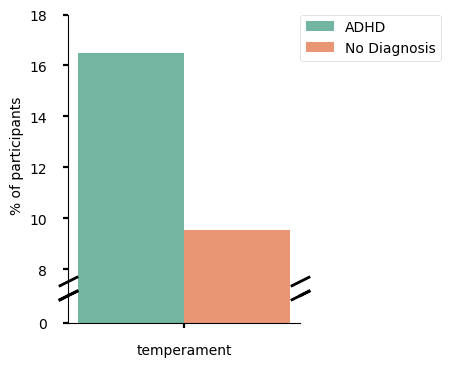

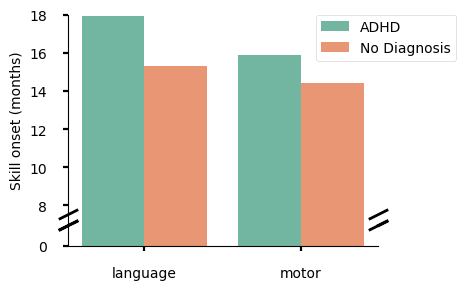

In [123]:
vis.plotting_style(palette='Set2')

# A # 
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(3, 4)

# get infant data
df_infant = get_infant_data(df_puberty, groupby=['DX_ADHD_binary'])
df1 = df_infant.groupby(['DX_ADHD_binary', 'type']).mean().reset_index()

ax1 = vis.barplot(x='type', y='values', hue='DX_ADHD_binary', data=df1.sort_values(by='DX_ADHD_binary', ascending=True), ylim=None, ylabel='% of participants',  xlabel='', ax=ax1)
ax2 = vis.barplot(x='type', y='values', hue='DX_ADHD_binary', data=df1.sort_values(by='DX_ADHD_binary', ascending=True), ylim=None, legend=False, ylabel='',  xlabel='', ax=ax2)
ax1.get_legend().set_bbox_to_anchor((1.0, 1.0))

ax1, ax2 = vis.modify_axes(ax1, ax2, ylim_outliers=(7, 18), ylim_data=(0,1))
vis._draw_cut(ax1, ax2)

# B # 
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(4, 3)

df_skills = get_skills_data(df_puberty, skills=['motor', 'language'], groupby=['DX_ADHD_binary'])
df1 = df_skills.groupby(['DX_ADHD_binary', 'type']).mean().reset_index()

ax1 = vis.barplot(x='type', y='values', hue='DX_ADHD_binary', data=df1.sort_values(by='DX_ADHD_binary', ascending=True), ylim=None, ylabel='Skill onset (months)',  xlabel='', ax=ax1)
ax2 = vis.barplot(x='type', y='values', hue='DX_ADHD_binary', data=df1.sort_values(by='DX_ADHD_binary', ascending=True), ylim=None, legend=False, ylabel='',  xlabel='', ax=ax2)

ax1, ax2 = vis.modify_axes(ax1, ax2, ylim_outliers=(7, 18), ylim_data=(0,1))
vis._draw_cut(ax1, ax2)
ax1.get_legend().set_bbox_to_anchor((.8, 1.0))

### More granular - infant temperment and skills

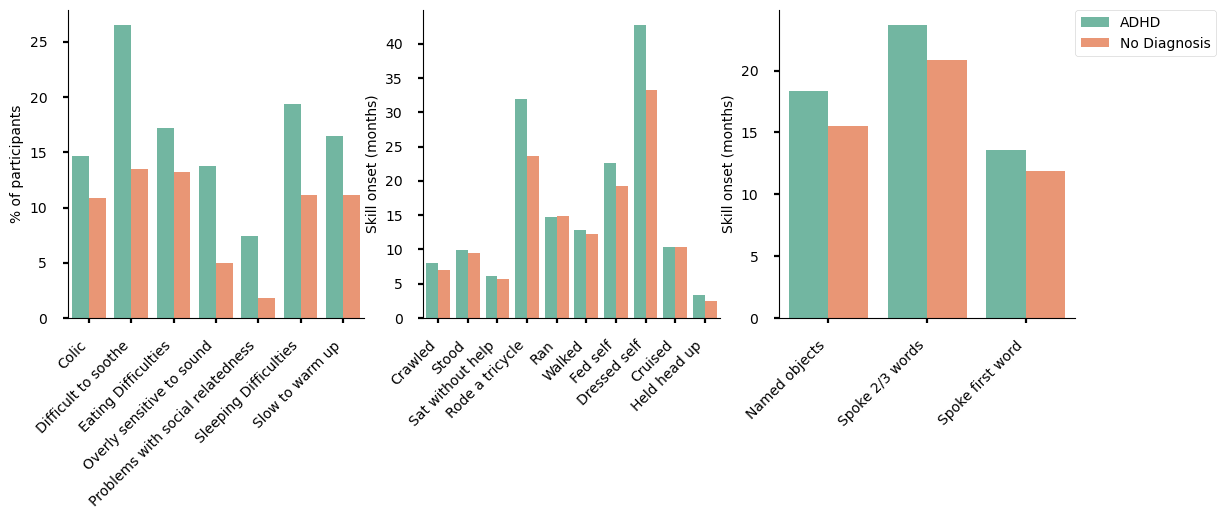

In [130]:
vis.plotting_style(palette='Set2')
fig = plt.figure(figsize=(13,4))
gs = GridSpec(1, 3, figure=fig)

# A # 
df_infant = get_infant_data(df_puberty, groupby=['DX_ADHD_binary'])
df1 = df_infant.groupby(['DX_ADHD_binary', 'cols', 'type']).mean().reset_index()

ax = fig.add_subplot(gs[0, 0])
ax = vis.barplot(x='cols', y='values', hue='DX_ADHD_binary', data=df1.sort_values(by='DX_ADHD_binary'), 
                 ylim=None, ylabel='% of participants', legend=False, ax=ax)
plt.xticks(rotation=45, ha='right');

# B # 
df_skills = get_skills_data(df_puberty, skills=['motor', 'language'], groupby=['DX_ADHD_binary'])
df1 = df_skills.groupby(['DX_ADHD_binary', 'cols', 'type']).mean().reset_index()

ax = fig.add_subplot(gs[0, 1])
ax = vis.barplot(x='cols', y='values', hue='DX_ADHD_binary', data=df1[(df1['type'].isin(['motor'])) & (df1['cols']!='Tied shoes')] \
                 .sort_values(by='DX_ADHD_binary'), legend=False, \
                 ylim=None, ylabel='Skill onset (months)', ax=ax)
plt.xticks(rotation=45, ha='right');

# C # 
ax = fig.add_subplot(gs[0, 2])
ax = vis.barplot(x='cols', y='values', hue='DX_ADHD_binary', \
                data=df1[df1['type']=='language'].sort_values(by='DX_ADHD_binary'), \
                ylim=None, ylabel='Skill onset (months)',  ax=ax) 
plt.xticks(rotation=45, ha='right');
ax.get_legend().set_bbox_to_anchor((1.0, 1.0))

### Sex differences

In [15]:
## GET DATA ##

df_puberty = get_data(
        measure='PreInt_DevHx',
        assessment='Parent',
        dx='DX_ADHD',
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'No Diagnosis'],
        )

# get skills data
df_skills = get_skills_data(df_puberty, skills=['motor', 'language'], groupby=['DX_ADHD', 'Sex'])
df_skills['DX_ADHD'] = df_skills['DX_ADHD'].str.extract('(ADHD|No Diagnosis)').rename(columns={0:'DX_ADHD'})

# get infant data
df_infant = get_infant_data(df_puberty, groupby=['DX_ADHD', 'Sex'])
df_infant['DX_ADHD'] = df_infant['DX_ADHD'].str.extract('(ADHD|No Diagnosis)').rename(columns={0:'DX_ADHD'})
df_infant = df_infant.groupby(['DX_ADHD', 'Sex', 'cols', 'type']).mean().reset_index()

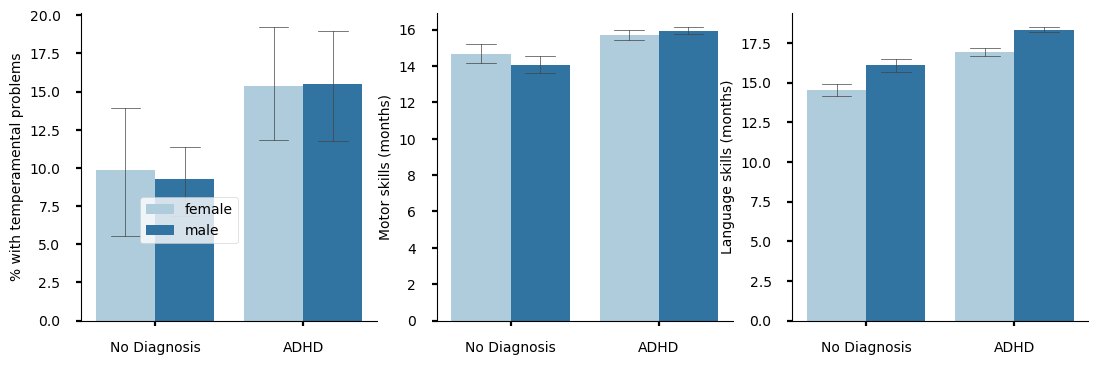

In [16]:
vis.plotting_style()
fig = plt.figure(figsize=(13,4))
gs = GridSpec(1, 3, figure=fig)

ax = fig.add_subplot(gs[0, 0])
ax = vis.barplot(x='DX_ADHD', y='values', hue='Sex', 
                 data=df_infant.sort_values(by='DX_ADHD', ascending=False), ylim=None, ylabel='% with temperamental problems', xlabel='', ax=ax)

ax = fig.add_subplot(gs[0, 1])
ax = vis.barplot(x='DX_ADHD', y='values', hue='Sex', data=df_skills[df_skills['type']=='motor'], ylim=None, ylabel='Motor skills (months)', legend=False, xlabel='', ax=ax)

ax = fig.add_subplot(gs[0, 2])
ax = vis.barplot(x='DX_ADHD', y='values', hue='Sex', data=df_skills[df_skills['type']=='language'], ylim=None, ylabel='Language skills (months)', legend=False, xlabel='', ax=ax)


### Subtype differences

In [10]:
## GET DATA ##

dx = 'DX_Subtype_Name'
df_puberty = get_data(
        measure='PreInt_DevHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
        )

# get skills data
df_skills = get_skills_data(df_puberty, skills=['motor', 'language'], groupby=['Identifiers', dx])

# get infant data
df_infant = get_infant_data(df_puberty, groupby=[dx])
df_infant = df_infant.groupby([dx, 'cols', 'type']).mean().reset_index()

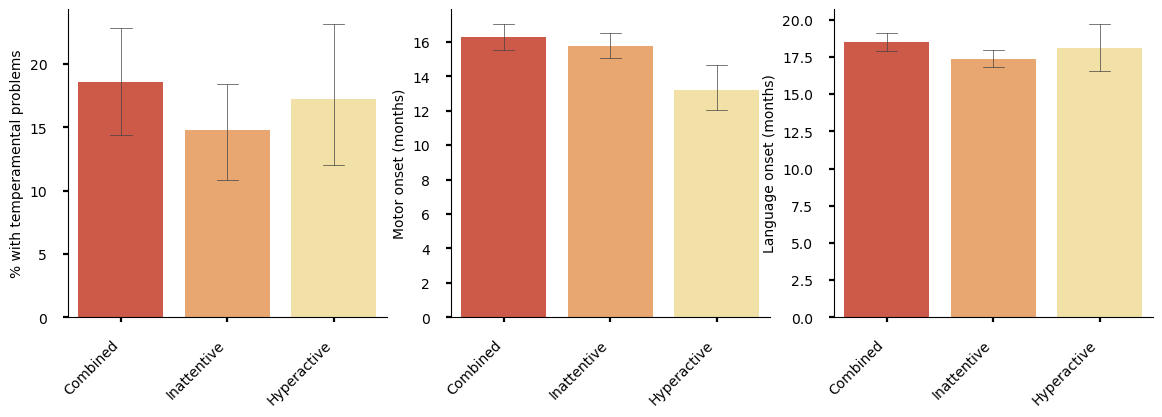

In [12]:
vis.plotting_style(palette='RdYlGn')
fig = plt.figure(figsize=(14,4))
gs = GridSpec(1, 3, figure=fig)

ax = fig.add_subplot(gs[0, 0])
order = ['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)']
xticklabels = ['Combined', 'Inattentive', 'Hyperactive']
ax = vis.barplot(x='DX_Subtype_Name', y='values',
                 data=df_infant.sort_values(by='DX_Subtype_Name', ascending=False), \
                 order=order, xticklabels=xticklabels,
                 ylim=None, ylabel='% with temperamental problems', xlabel='', ax=ax)
plt.xticks(rotation=45, ha='right');

ax = fig.add_subplot(gs[0, 1])
ax = vis.barplot(x='DX_Subtype_Name', y='values', data=df_skills[df_skills['type']=='motor'], \
                 order=order, xticklabels=xticklabels,
                 ylim=None, ylabel='Motor onset (months)', legend=False, xlabel='', ax=ax)
plt.xticks(rotation=45, ha='right');

ax = fig.add_subplot(gs[0, 2])
ax = vis.barplot(x='DX_Subtype_Name', y='values',  data=df_skills[df_skills['type']=='language'], \
                 order=order, xticklabels=xticklabels,
                 ylim=None, ylabel='Language onset (months)', legend=False, xlabel='', ax=ax)
plt.xticks(rotation=45, ha='right');

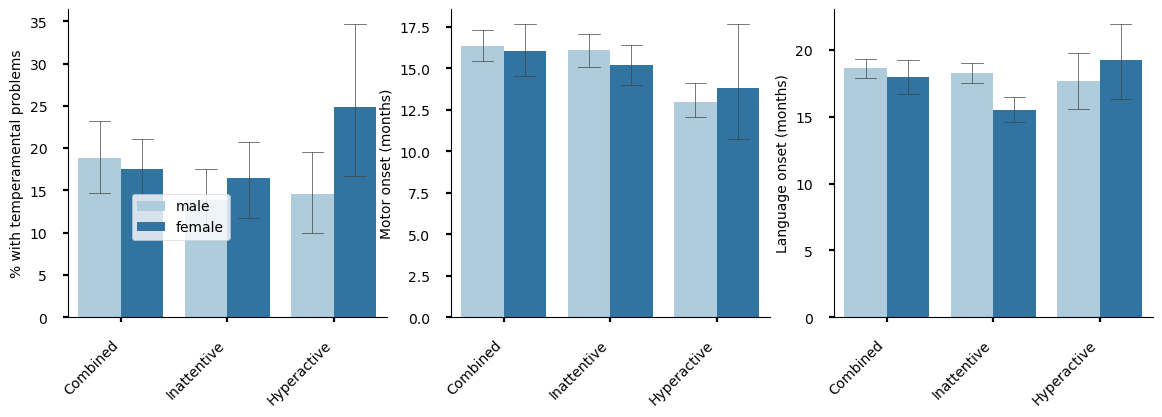

In [17]:
## GET DATA ##

dx = 'DX_Subtype_Name'
df_puberty = get_data(
        measure='PreInt_DevHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],
        )

# get skills data
df_skills = get_skills_data(df_puberty, skills=['motor', 'language'], groupby=['Identifiers', dx, 'Sex'])

# get infant data
df_infant = get_infant_data(df_puberty, groupby=[dx, 'Sex'])
df_infant = df_infant.groupby([dx, 'cols', 'type', 'Sex']).mean().reset_index()

vis.plotting_style(palette='Paired')
fig = plt.figure(figsize=(14,4))
gs = GridSpec(1, 3, figure=fig)

ax = fig.add_subplot(gs[0, 0])
order = ['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)']
xticklabels = ['Combined', 'Inattentive', 'Hyperactive']
ax = vis.barplot(x='DX_Subtype_Name', y='values',
                 data=df_infant.sort_values(by='DX_Subtype_Name', ascending=False), \
                 order=order, xticklabels=xticklabels, hue='Sex', 
                 ylim=None, ylabel='% with temperamental problems', xlabel='', ax=ax)
plt.xticks(rotation=45, ha='right');

ax = fig.add_subplot(gs[0, 1])
ax = vis.barplot(x='DX_Subtype_Name', y='values', data=df_skills[df_skills['type']=='motor'], \
                 order=order, xticklabels=xticklabels, hue='Sex',
                 ylim=None, ylabel='Motor onset (months)', legend=False, xlabel='', ax=ax)
plt.xticks(rotation=45, ha='right');

ax = fig.add_subplot(gs[0, 2])
ax = vis.barplot(x='DX_Subtype_Name', y='values',  data=df_skills[df_skills['type']=='language'], \
                 order=order, xticklabels=xticklabels, hue='Sex',
                 ylim=None, ylabel='Language onset (months)', legend=False, xlabel='', ax=ax)
plt.xticks(rotation=45, ha='right');

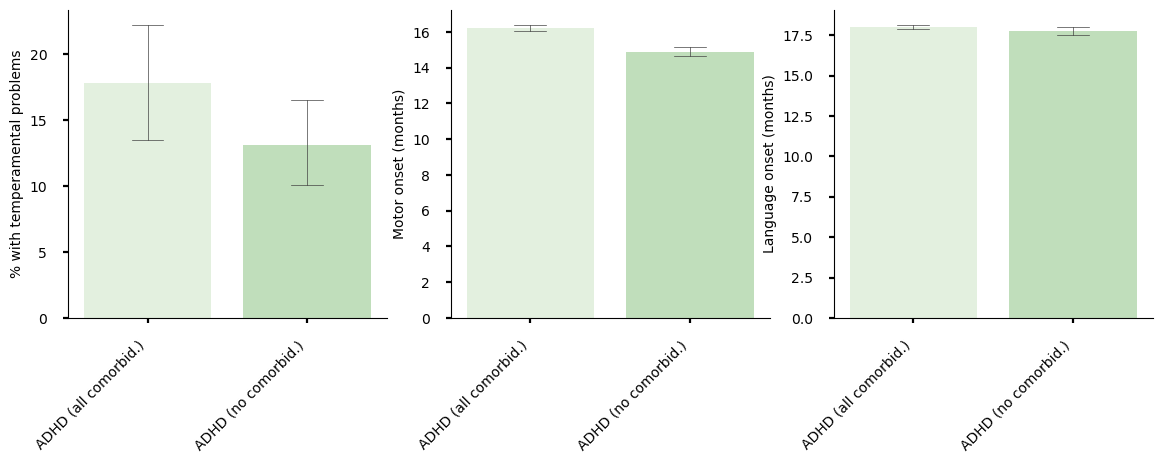

In [13]:
dx = 'DX_ADHD'
df_puberty = get_data(
        measure='PreInt_DevHx',
        assessment='Parent',
        dx=dx,
        dx_to_include=['ADHD (all comorbid.)', 'ADHD (no comorbid.)'],
        )

# get skills data
df_skills = get_skills_data(df_puberty, skills=['motor', 'language'], groupby=['Identifiers', dx])

# get infant data
df_infant = get_infant_data(df_puberty, groupby=[dx])
df_infant = df_infant.groupby([dx, 'cols', 'type']).mean().reset_index()

vis.plotting_style(palette='Greens')
fig = plt.figure(figsize=(14,4))
gs = GridSpec(1, 3, figure=fig)

ax = fig.add_subplot(gs[0, 0])
ax = vis.barplot(x='DX_ADHD', y='values',
                 data=df_infant, 
                 ylim=None, ylabel='% with temperamental problems', xlabel='', ax=ax)
plt.xticks(rotation=45, ha='right');

ax = fig.add_subplot(gs[0, 1])
ax = vis.barplot(x='DX_ADHD', y='values', data=df_skills[df_skills['type']=='motor'], \
                 ylim=None, ylabel='Motor onset (months)', legend=False, xlabel='', ax=ax)
plt.xticks(rotation=45, ha='right');

ax = fig.add_subplot(gs[0, 2])
ax = vis.barplot(x='DX_ADHD', y='values',  data=df_skills[df_skills['type']=='language'], \
                 ylim=None, ylabel='Language onset (months)', legend=False, xlabel='', ax=ax)
plt.xticks(rotation=45, ha='right');
